# EDA

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt 
import pyarrow.parquet as pq
import warnings
warnings.filterwarnings("ignore")
from src.visualization.tariff_plot import plot_monthly_adoption, plot_monthly_share, plot_tariff_group_counts, plot_tariff_group_cumulative 
from src.visualization.consumption_plot import plot_consumption, plot_tariff_adoption_by_usage, plot_event_study_tariff, plot_tariff_adoption
from src.visualization.consumption_cohort import plot_cohort_calendar, plot_multiple_cohorts, plot_cohort_panels
from src.visualization import peak_plot as pp

## Load Data

In [2]:
# data paths
DATA_DIR_MOCK = "mock_data"
DATA_DIR_AGG = "output/data"
OUT_BASE_DIR = "output"

# Load aggregated data paths
MATDATA_PATH_MONTHLY = os.path.join(DATA_DIR_AGG, "monthly_agg.parquet")
MATDATA_PATH_HOURLY = os.path.join(DATA_DIR_AGG, "hourly_agg.parquet")
MATDATA_PATH_WEEKLY = os.path.join(DATA_DIR_AGG, "weekly_agg.parquet")

# Load mock tariff and survey data paths
TARIFF_PATH  = os.path.join(DATA_DIR_MOCK, "tariff_100.csv")
SURVEY_PATH  = os.path.join(DATA_DIR_MOCK, "survey_50.csv")

In [3]:
# Monthly aggregated data
pf = pq.ParquetFile(MATDATA_PATH_MONTHLY)
table = pf.read()
month_result = table.to_pandas()
month_result.head()


,aID,TIDPUNKT,price,tariff_active,peak1_consumption,peak2_consumption,peak3_consumption,peak1_time,peak2_time,peak3_time,top3_mean_consumption,variance_consumption,mean_consumption,tariff_start,tariff_plan,total_consumption,usage_group
0,735999166200000851,2024-01-01,all,0,0.785776,0.771093,0.766627,2024-01-08 19:00:00,2024-01-06 18:00:00,2024-01-07 19:00:00,0.774499,0.022423,0.378508,NaT,NaN,6334.57217,low
1,735999166200000851,2024-01-01,high,0,0.785776,0.739500,0.709986,2024-01-08 19:00:00,2024-01-01 19:00:00,2024-01-17 19:00:00,0.745087,0.023170,0.386800,NaT,NaN,6334.57217,low
2,735999166200000851,2024-01-01,low,0,0.771093,0.766627,0.758738,2024-01-06 18:00:00,2024-01-07 19:00:00,2024-01-20 18:00:00,0.765486,0.021895,0.372936,NaT,NaN,6334.57217,low
3,735999166200000851,2024-02-01,all,0,0.790864,0.782472,0.780223,2024-02-24 19:00:00,2024-02-25 20:00:00,2024-02-15 19:00:00,0.784520,0.023686,0.379428,NaT,NaN,6334.57217,low
4,735999166200000851,2024-02-01,high,0,0.780223,0.743266,0.720648,2024-02-15 19:00:00,2024-02-07 19:00:00,2024-02-09 19:00:00,0.748046,0.024711,0.385561,NaT,NaN,6334.57217,low


In [4]:
# pd.set_option('display.max_rows', None)
# chunk_size = 5000

# for i in range(0, len(month_result), chunk_size):
#     print(f"Rows {i} to {i+chunk_size}")
#     display(month_result.iloc[i:i+chunk_size])

In [5]:
# Hourly aggregated data
pf = pq.ParquetFile(MATDATA_PATH_HOURLY)
table = pf.read()
hourly_result = table.to_pandas()
hourly_result.head()

,aID,TIDPUNKT,price,tariff_active,mean_consumption,tariff_start,tariff_plan,total_consumption,usage_group
0,735999166200000851,0,all,0,0.217603,NaT,NaN,6334.57217,low
1,735999166200000851,1,all,0,0.217461,NaT,NaN,6334.57217,low
2,735999166200000851,2,all,0,0.214411,NaT,NaN,6334.57217,low
3,735999166200000851,3,all,0,0.221231,NaT,NaN,6334.57217,low
4,735999166200000851,4,all,0,0.235604,NaT,NaN,6334.57217,low


In [6]:
# Weekly aggregated data
pf = pq.ParquetFile(MATDATA_PATH_WEEKLY)
table = pf.read()
weekly_result = table.to_pandas()
weekly_result.head()

,aID,TIDPUNKT,price,tariff_active,mean_consumption,tariff_start,tariff_plan,total_consumption,usage_group
0,735999166200000851,0,all,0,0.334415,NaT,NaN,6334.57217,low
1,735999166200000851,1,all,0,0.333322,NaT,NaN,6334.57217,low
2,735999166200000851,2,all,0,0.333210,NaT,NaN,6334.57217,low
3,735999166200000851,3,all,0,0.331530,NaT,NaN,6334.57217,low
4,735999166200000851,4,all,0,0.332026,NaT,NaN,6334.57217,low


In [7]:
# Tariff data
tariff_df = pd.read_csv(TARIFF_PATH, sep=",")
print(f"tariff rows: {len(tariff_df):,}") # Tariff number 
display(tariff_df.head(3))

# Survey data
# survey_month_result[month_result["price"] == "high"] = pd.read_csv(SURVEY_PATH)
# print(f"survey rows: {len(survey_month_result[month_result["price"] == "high"]):,}") # Survey number
# display(survey_month_result[month_result["price"] == "high"].head(3))


tariff rows: 100


,Produktnamn,Startdatum,GS1-nr.
0,GENAB Tidsindelad 6 kW Villa,2025-06-01,735999166200288372
1,GENAB Tidsindelad 6 kW Villa,2025-04-01,735999166200186244
2,GENAB Tidsindelad 6 kW Villa,2025-03-01,735999166200055594


# Start EDA - Tariff

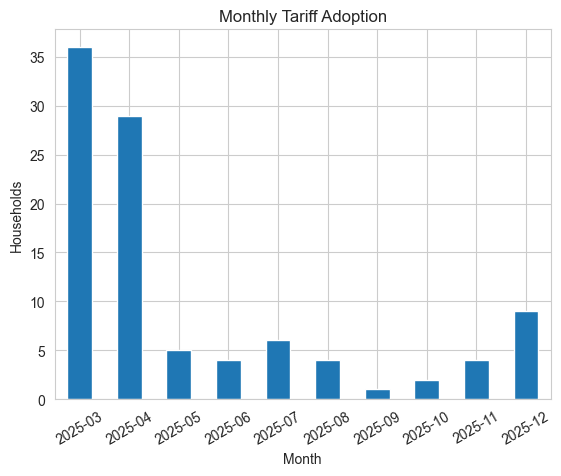

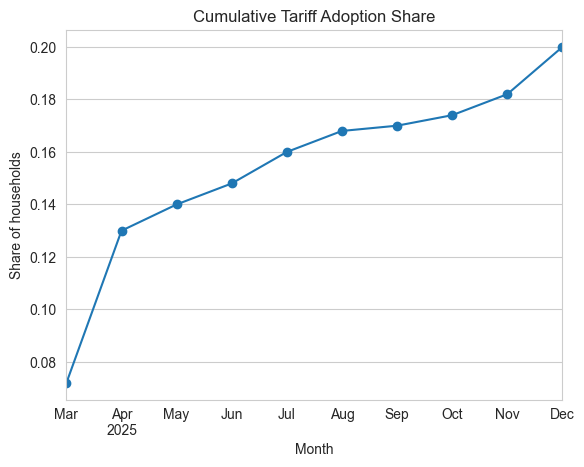

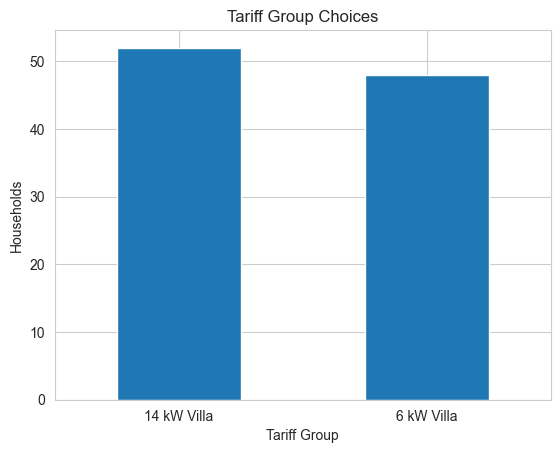

<Figure size 640x480 with 0 Axes>

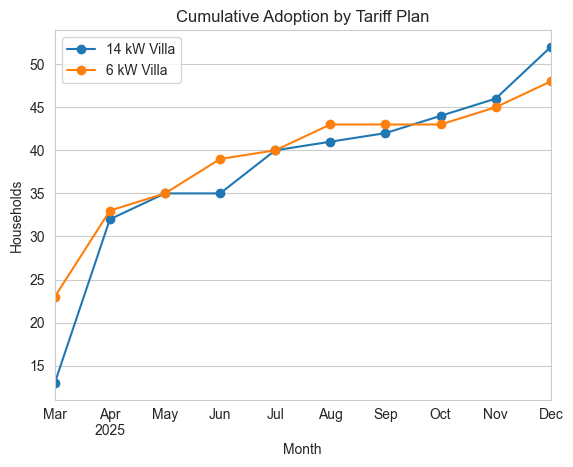

In [8]:
plot_monthly_adoption(tariff_df)
plt.show()

plot_monthly_share(tariff_df, total_households=500)
plt.show()

plot_tariff_group_counts(tariff_df)
plt.show()

plot_tariff_group_cumulative(tariff_df)
plt.show()

## Electricity data

<Axes: title={'center': 'Average Monthly Peak Consumption'}, xlabel='Month', ylabel='Average Peak Consumption (Top 3 Hours, kWh)'>

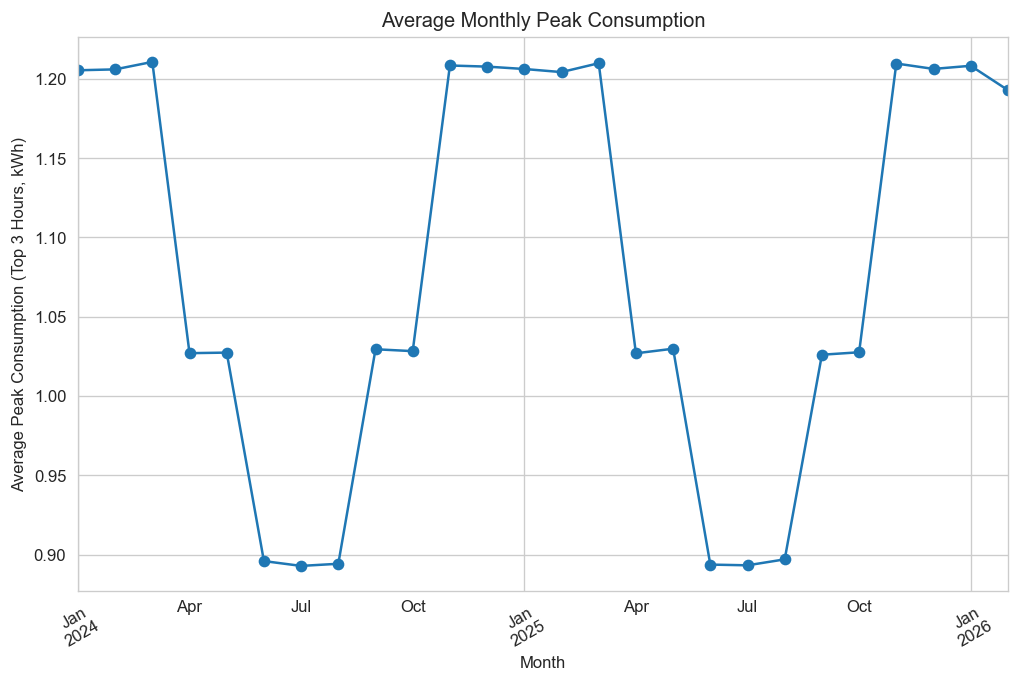

In [9]:
plot_consumption(
    month_result[month_result["price"] == "all"],
    group_by="month",
    value_col="top3_mean_consumption",
    show_legend=False
)

<Axes: title={'center': 'Average Monthly Peak Consumption'}, xlabel='Month', ylabel='Average Peak Consumption (Top 3 Hours, kWh)'>

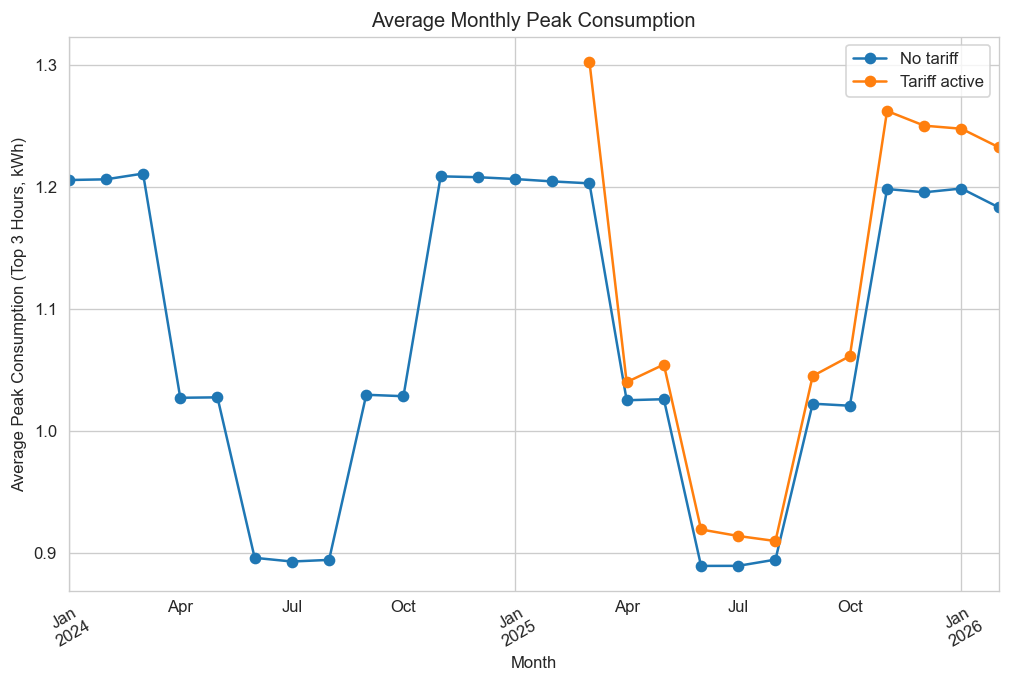

In [10]:
plot_consumption(
    month_result[month_result["price"] == "all"],
    group_by="month",
    value_col="top3_mean_consumption",
    splits=["tariff_active"],
)

Before: 13000
After: 11372


<Axes: title={'center': 'Average Monthly Peak Consumption (Control group: Non-adopters)'}, xlabel='Month', ylabel='Average Peak Consumption (Top 3 Hours, kWh)'>

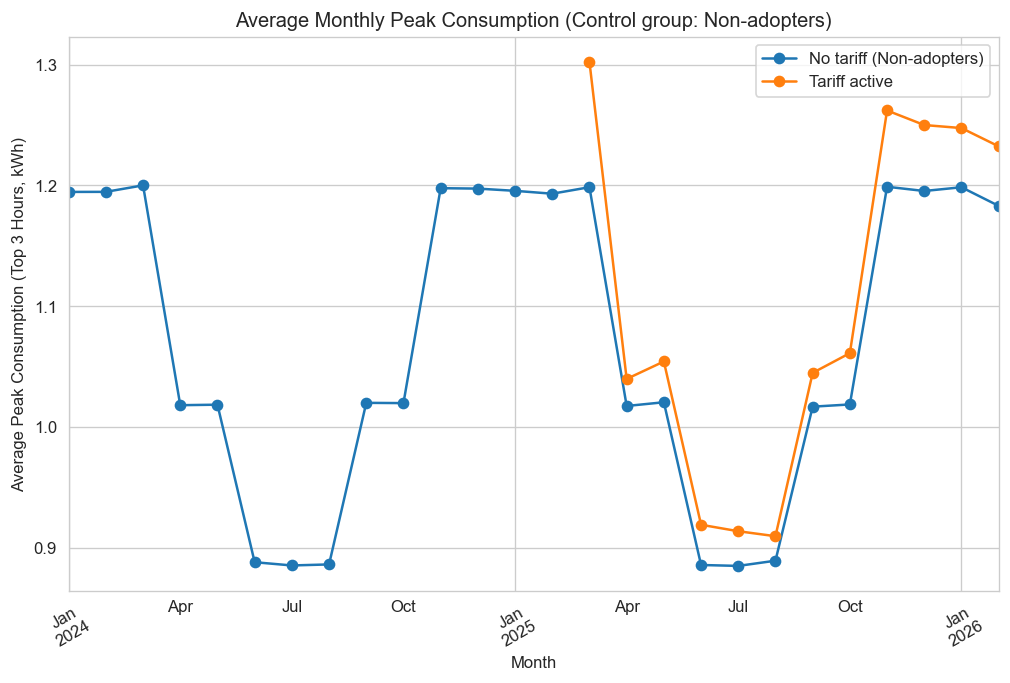

In [11]:
plot_consumption(
    month_result[month_result["price"] == "all"],
    group_by="month",
    value_col="top3_mean_consumption",
    splits=["tariff_active"],
    exclude_future_tariff=True
)

<Axes: title={'center': 'Average Monthly Peak Consumption'}, xlabel='Month', ylabel='Average Peak Consumption (Top 3 Hours, kWh)'>

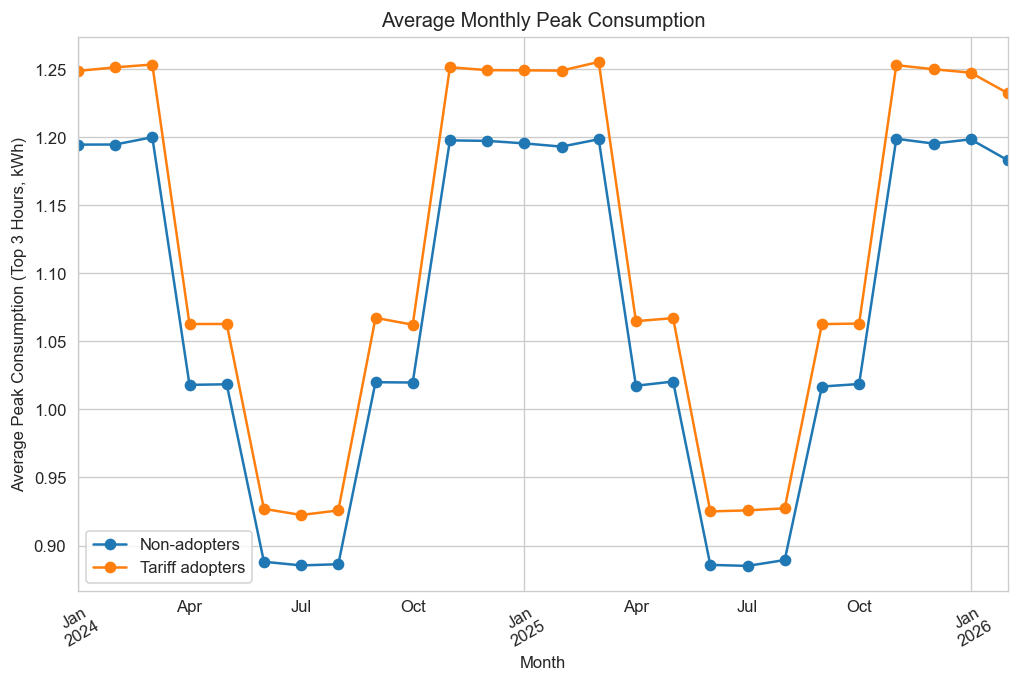

In [12]:
plot_tariff_adoption(
    month_result[month_result["price"] == "all"],
    group_by="month",
    value_col="top3_mean_consumption"
)

<Axes: title={'center': 'Average Monthly Peak Consumption'}, xlabel='Month', ylabel='Average Peak Consumption (Top 3 Hours, kWh)'>

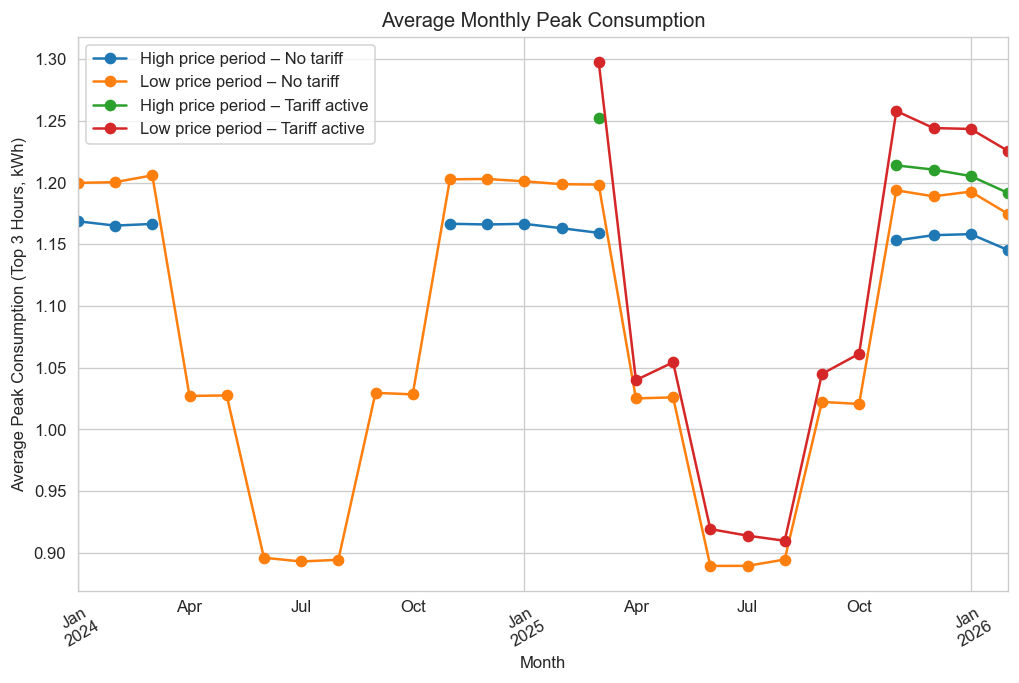

In [13]:
plot_consumption(
    month_result,
    group_by="month",
    value_col="top3_mean_consumption",
    splits=["price","tariff_active"]
)

Before: 32000
After: 27971


<Axes: title={'center': 'Average Monthly Peak Consumption (Control group: Non-adopters)'}, xlabel='Month', ylabel='Average Peak Consumption (Top 3 Hours, kWh)'>

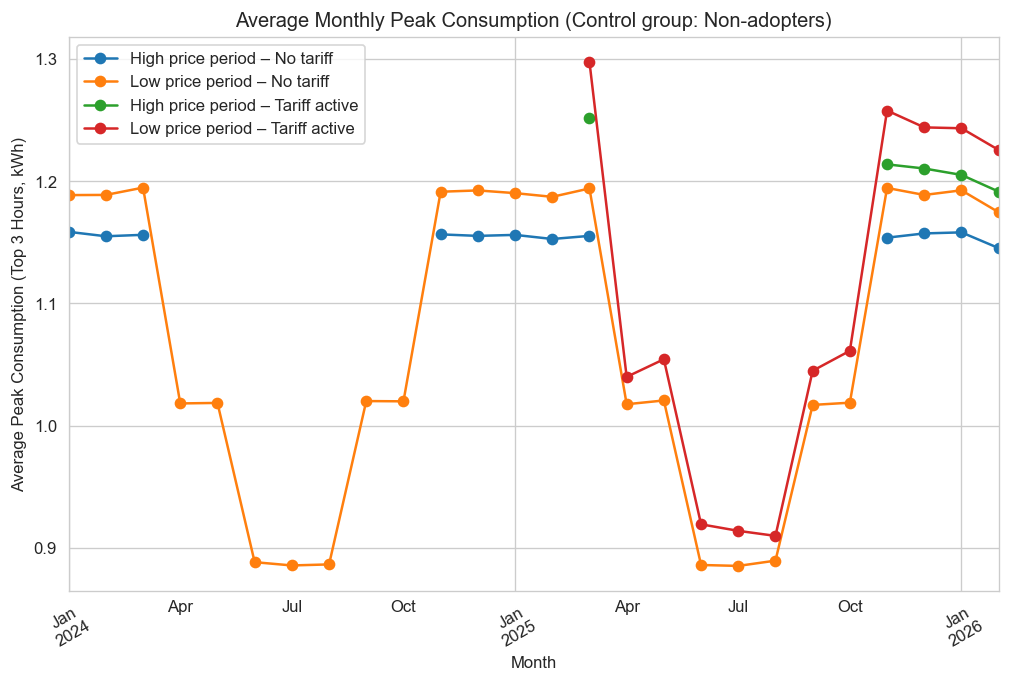

In [14]:
plot_consumption(
    month_result,
    group_by="month",
    value_col="top3_mean_consumption",
    splits=["price","tariff_active"],
    exclude_future_tariff=True
)

<Axes: title={'center': 'Average Monthly Peak Consumption'}, xlabel='Month', ylabel='Average Peak Consumption (Top 3 Hours, kWh)'>

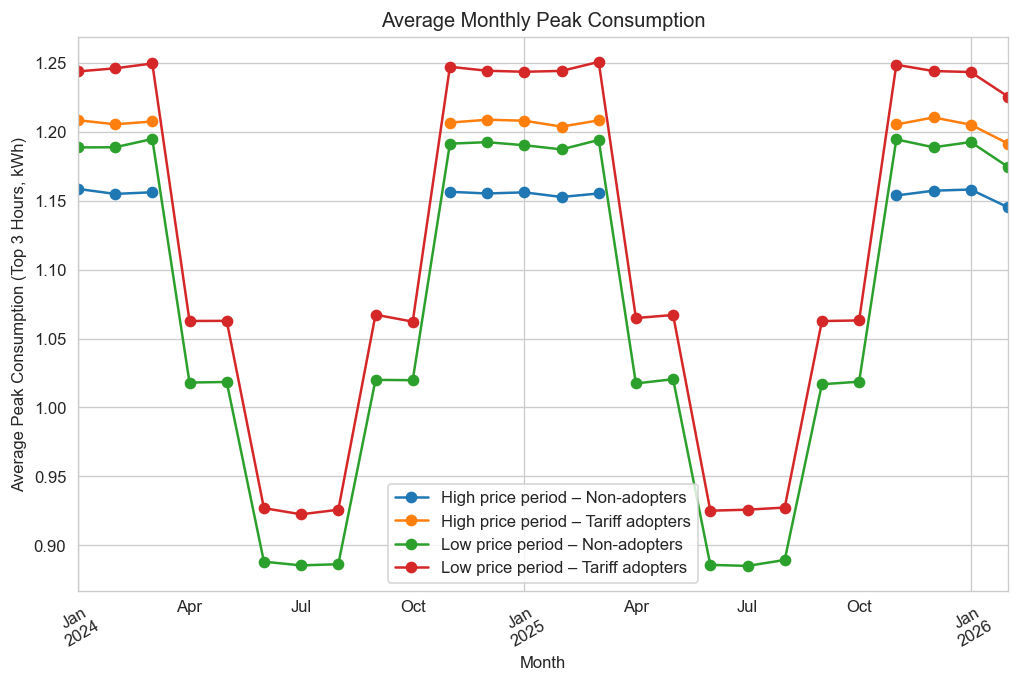

In [15]:
plot_tariff_adoption(
    month_result,
    group_by="month",
    value_col="top3_mean_consumption",
    by_price=True
)

<Axes: title={'center': 'Average Hourly Consumption Profile'}, xlabel='Hour of Day', ylabel='Average Electricity Consumption (kWh)'>

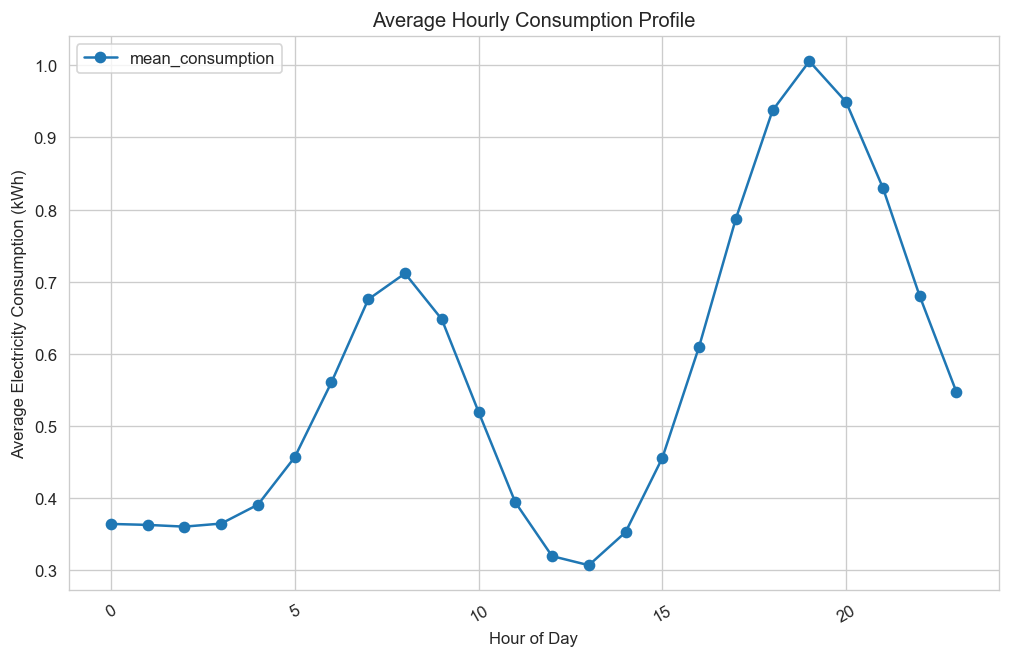

In [16]:
# hour
plot_consumption(
    hourly_result,
    group_by="hour",
    value_col="mean_consumption",
)

In [17]:
hourly_result.groupby("tariff_active").size()

tariff_active
0    30500
1     6100
dtype: int64

<Axes: title={'center': 'Average Hourly Consumption Profile'}, xlabel='Hour of Day', ylabel='Average Electricity Consumption (kWh)'>

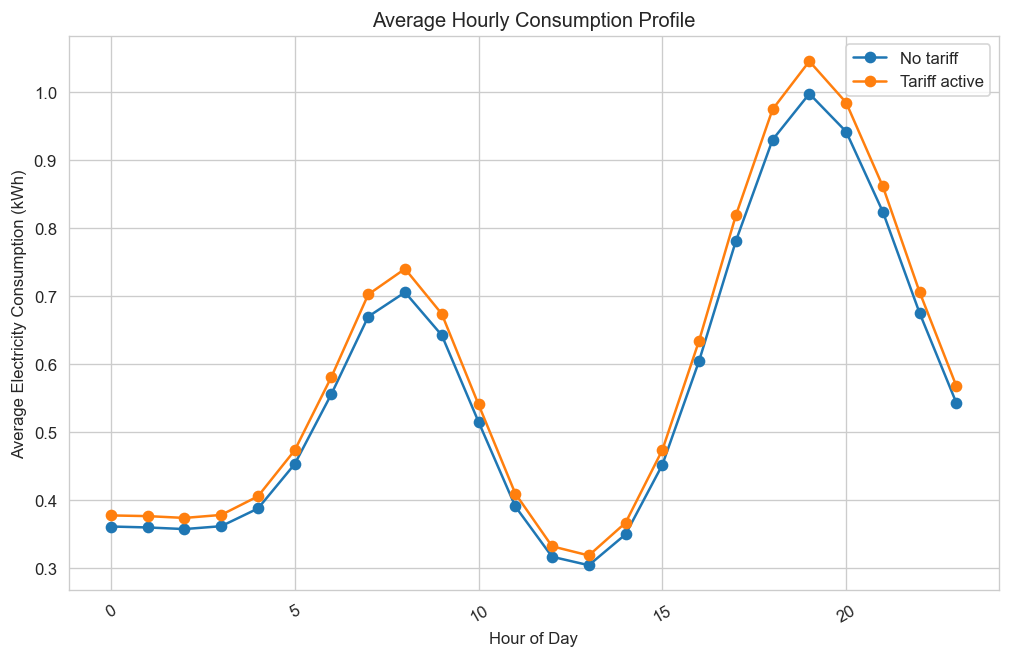

In [18]:
# hour
plot_consumption(
    hourly_result,
    group_by="hour",
    value_col="mean_consumption",
    splits=["tariff_active"]
)

Before: 36600
After: 30500


<Axes: title={'center': 'Average Hourly Consumption Profile (Control group: Non-adopters)'}, xlabel='Hour of Day', ylabel='Average Electricity Consumption (kWh)'>

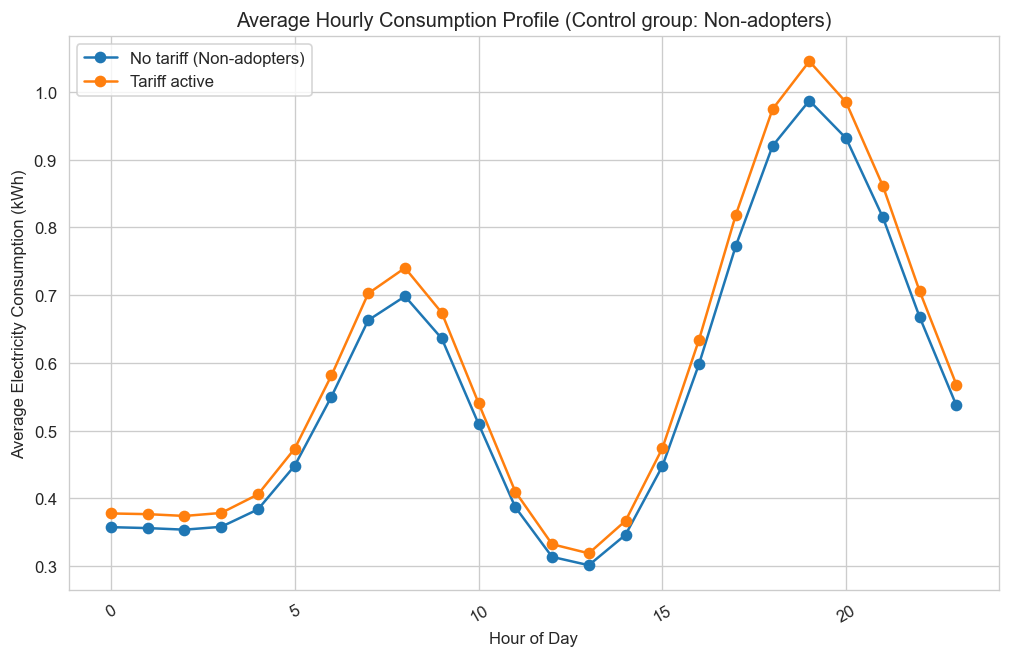

In [19]:
# hour
plot_consumption(
    hourly_result,
    group_by="hour",
    value_col="mean_consumption",
    splits=["tariff_active"],
    exclude_future_tariff=True
)

<Axes: title={'center': 'Average Hourly Consumption Profile'}, xlabel='Hour of Day', ylabel='Average Electricity Consumption (kWh)'>

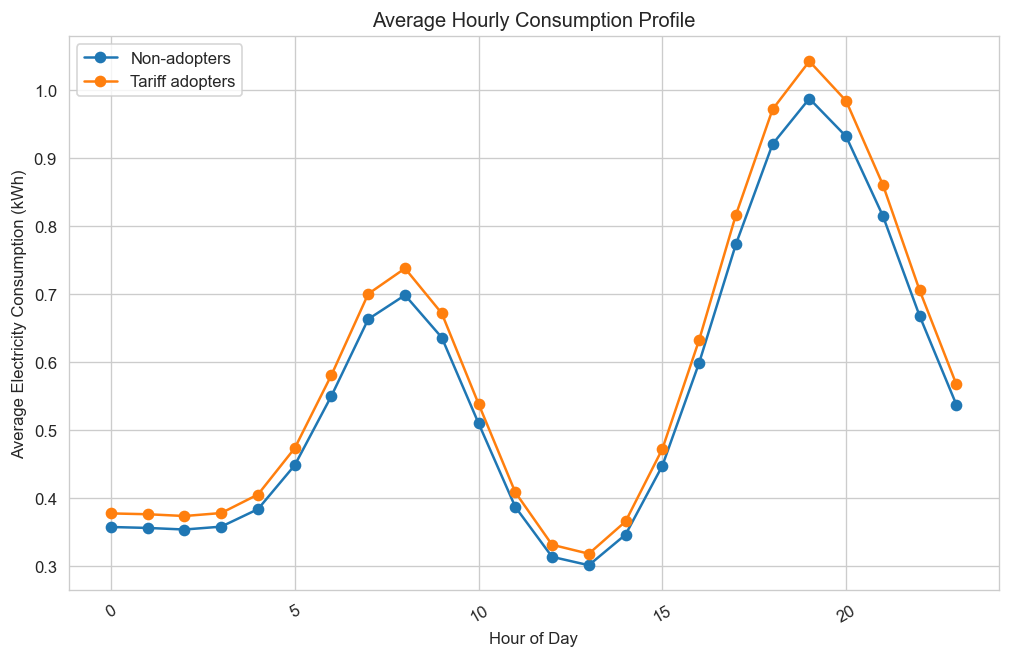

In [20]:
plot_tariff_adoption(
    hourly_result,
    group_by="hour",
    value_col="mean_consumption",
)

<Axes: title={'center': 'Average Consumption by Day of Week'}, xlabel='Day of Week', ylabel='Average Electricity Consumption (kWh)'>

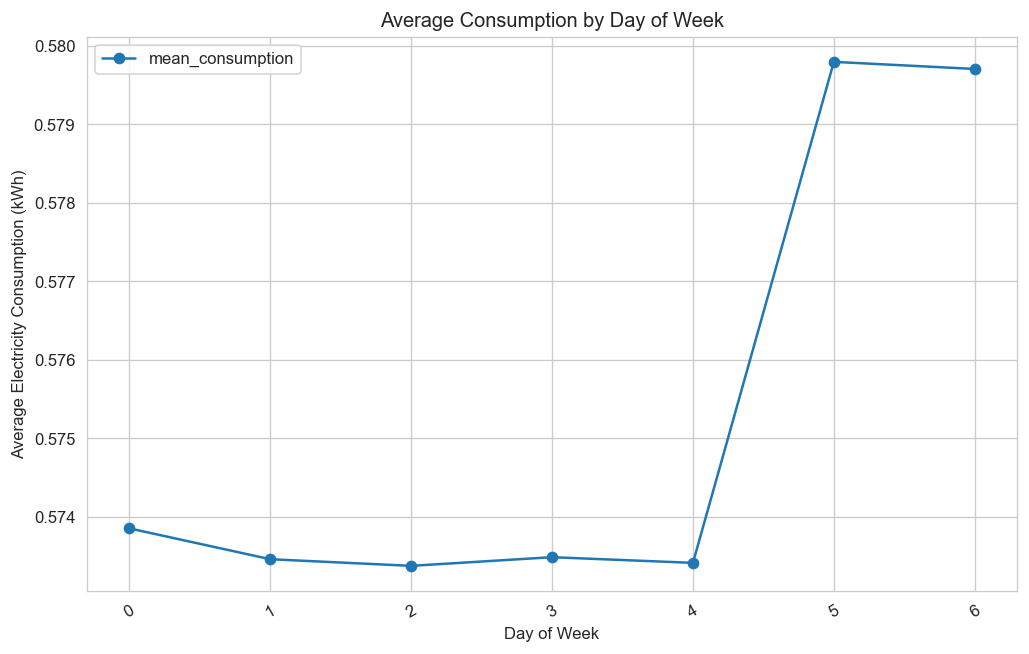

In [21]:
# weekend, week
plot_consumption(
    weekly_result,
    group_by="weekday",
    value_col="mean_consumption",
)

<Axes: title={'center': 'Electricity Consumption'}, xlabel='Month', ylabel='Average Electricity Consumption (kWh)'>

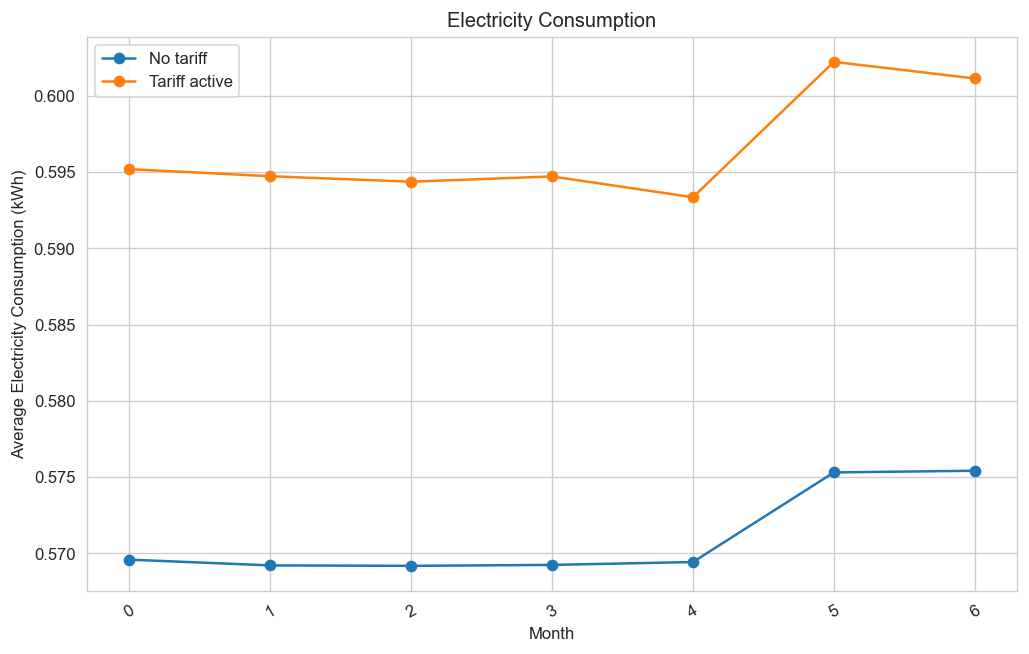

In [22]:
plot_consumption(
    weekly_result,
    group_by="week",
    value_col="mean_consumption",
    splits=["tariff_active"],
)

Before: 11400
After: 9500


<Axes: title={'center': 'Electricity Consumption (Control group: Non-adopters)'}, xlabel='Month', ylabel='Average Electricity Consumption (kWh)'>

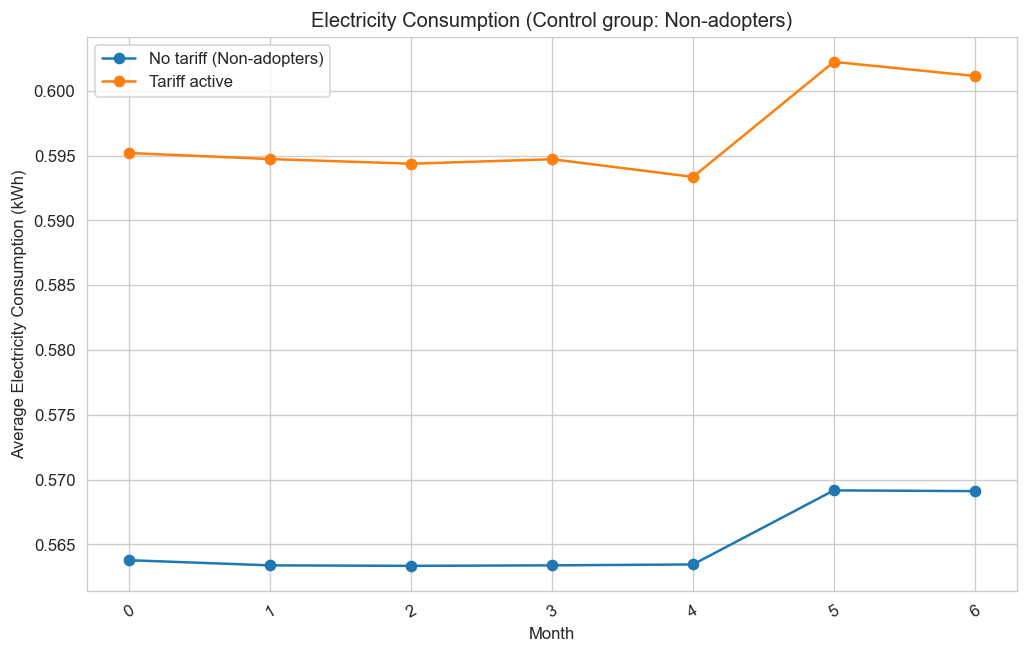

In [23]:
# hour
plot_consumption(
    weekly_result,
    group_by="week",
    value_col="mean_consumption",
    splits=["tariff_active"],
    exclude_future_tariff=True
)

<Axes: title={'center': 'Electricity Consumption'}, xlabel='Month', ylabel='Average Electricity Consumption (kWh)'>

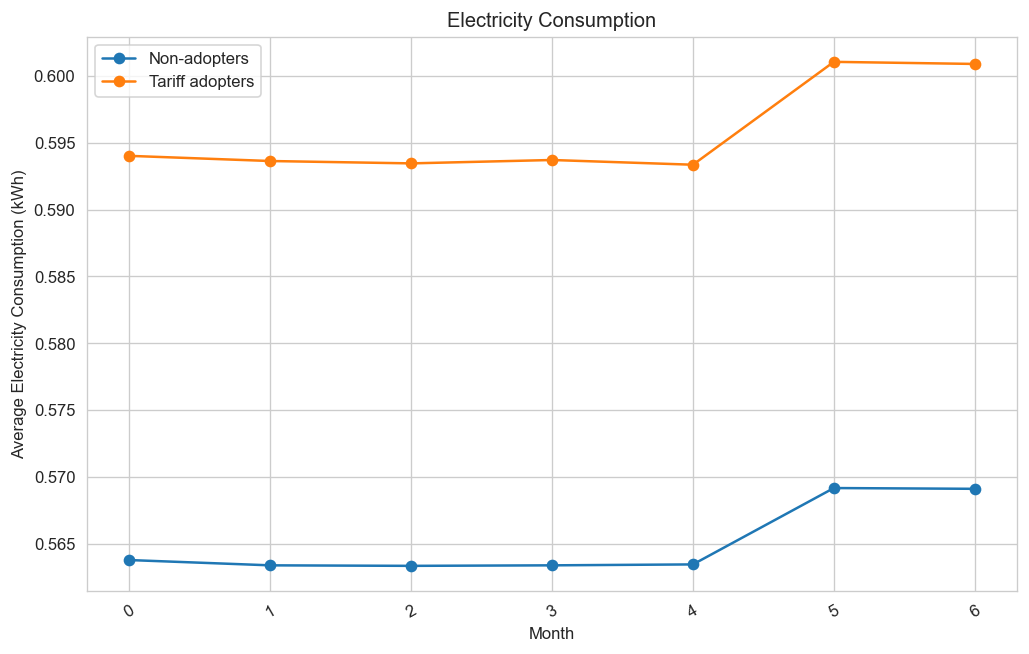

In [24]:
plot_tariff_adoption(
    weekly_result,
    group_by="week",
    value_col="mean_consumption",
)

<Axes: title={'center': 'Average Monthly Peak Consumption'}, xlabel='Month', ylabel='Average Peak Consumption (Top 3 Hours, kWh)'>

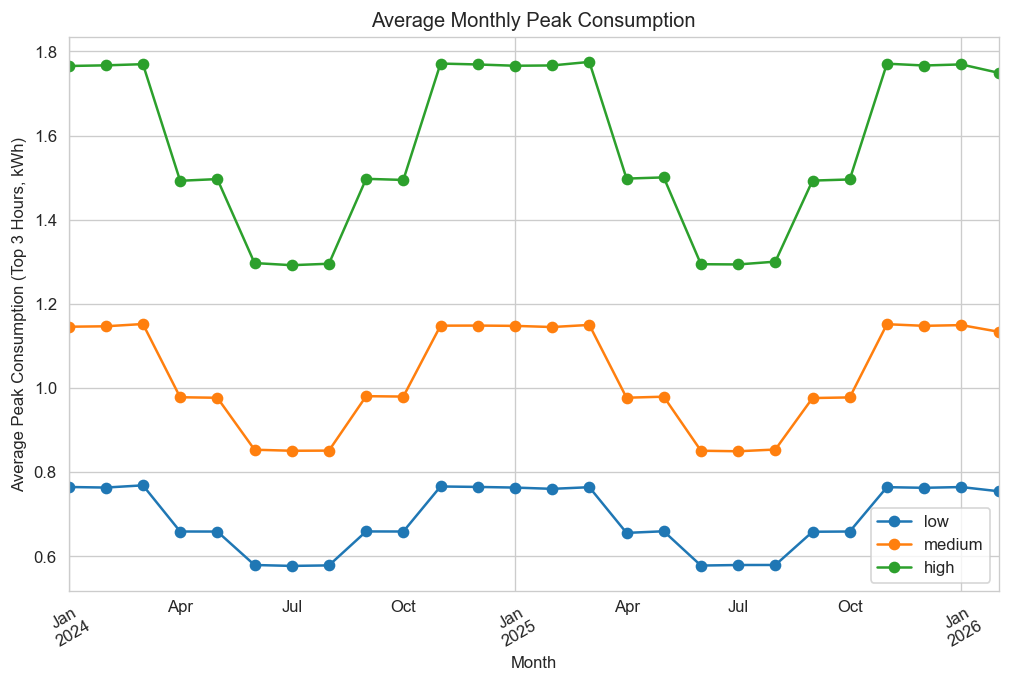

In [25]:
plot_consumption(
    month_result[month_result["price"] == "all"],
    group_by="month",
    value_col="top3_mean_consumption",
    splits=["usage_group"]
)

array([<Axes: title={'center': 'High'}, xlabel='Month', ylabel='Average Peak Consumption (Top 3 Hours, kWh)'>,
       <Axes: title={'center': 'Low'}, xlabel='Month'>,
       <Axes: title={'center': 'Medium'}, xlabel='Month'>], dtype=object)

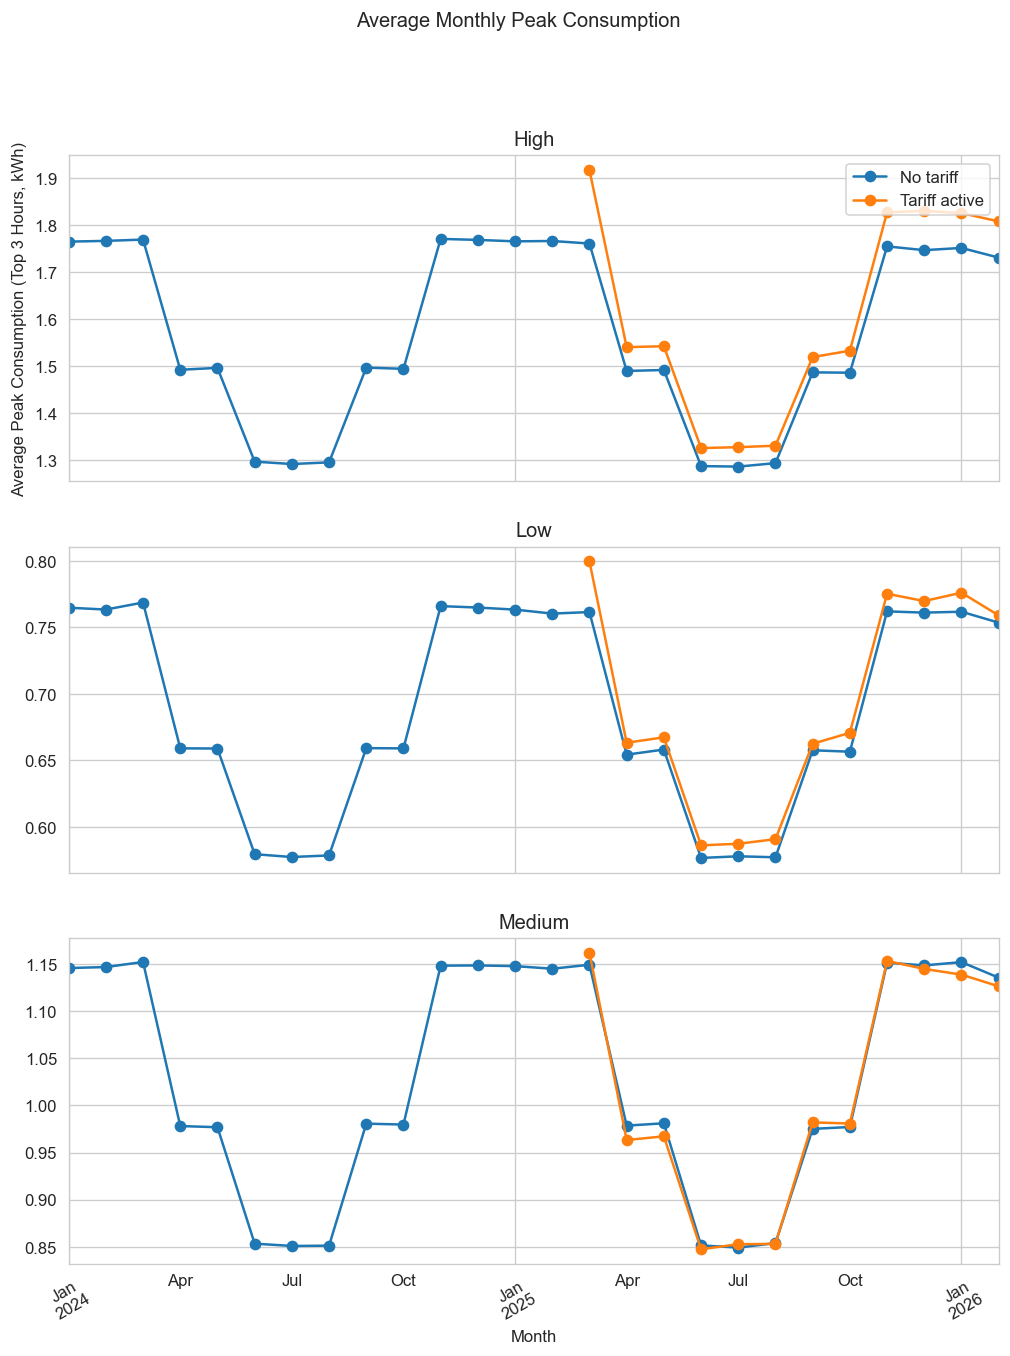

In [26]:
plot_consumption(
    month_result[month_result["price"] == "all"],
    group_by="month",
    value_col="top3_mean_consumption",
    splits=["usage_group", "tariff_active"],
    facet_by="usage_group"
)

Before: 13000
After: 11372


array([<Axes: title={'center': 'High'}, xlabel='Month', ylabel='Average Peak Consumption (Top 3 Hours, kWh)'>,
       <Axes: title={'center': 'Low'}, xlabel='Month'>,
       <Axes: title={'center': 'Medium'}, xlabel='Month'>], dtype=object)

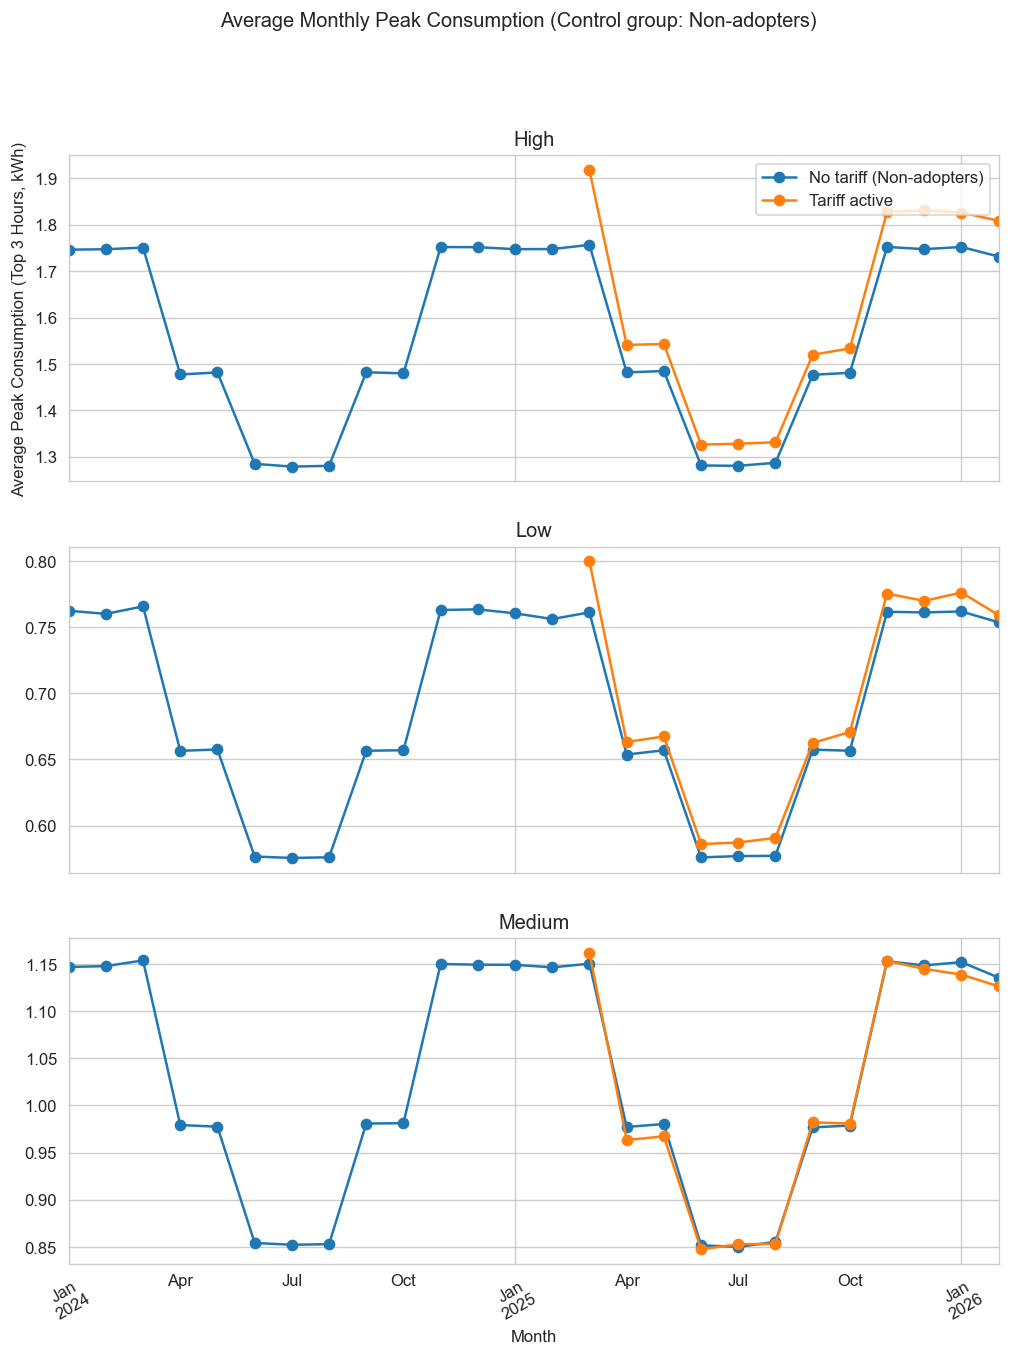

In [27]:
plot_consumption(
    month_result[month_result["price"] == "all"],
    group_by="month",
    value_col="top3_mean_consumption",
    splits=["usage_group", "tariff_active"],
    exclude_future_tariff=True,
    facet_by="usage_group"
)

<Axes: title={'center': 'Tariff Adoption by Household Usage Group'}, xlabel='Household Usage Group', ylabel='Share Choosing Tariff'>

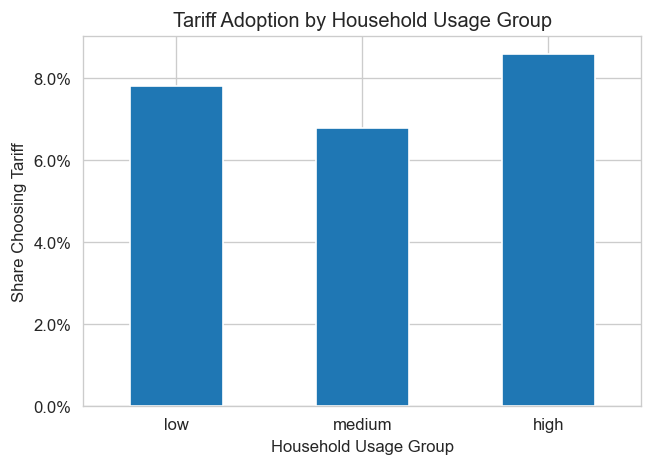

In [28]:
plot_tariff_adoption_by_usage(
    month_result[month_result["price"] == "all"],
    figsize=(6, 4)
)

<Axes: title={'center': 'Electricity Consumption Around Tariff Adoption'}, xlabel='Months Relative to Tariff Adoption', ylabel='Average Electricity Consumption (kWh)'>

<Figure size 640x480 with 0 Axes>

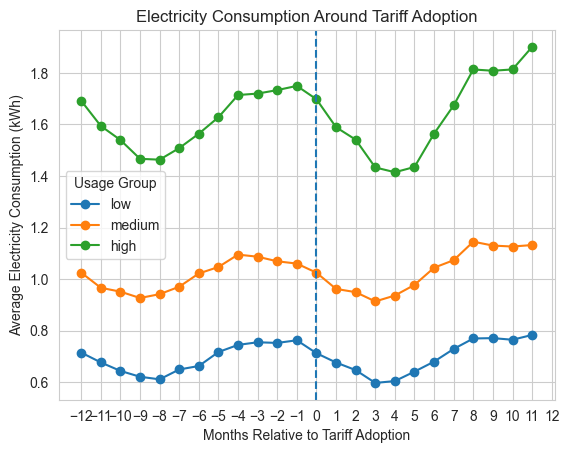

In [29]:
# 有選 tariff 的人的用電量平均變化 (按用電總量分組)
plot_event_study_tariff(
    month_result[month_result["price"] == "all"],
    value_col="top3_mean_consumption",
    line_cols="usage_group",
    window=12
)

<Axes: title={'center': 'Electricity Consumption Around Tariff Adoption'}, xlabel='Months Relative to Tariff Adoption', ylabel='Average Electricity Consumption (kWh)'>

<Figure size 640x480 with 0 Axes>

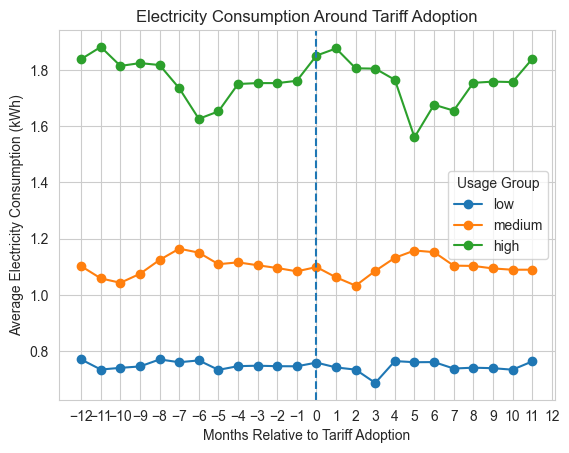

In [30]:
# 有選 tariff 的人的用電量平均變化 (按用電總量分組)
plot_event_study_tariff(
    month_result[month_result["price"] == "high"],
    value_col="top3_mean_consumption",
    line_cols="usage_group",
    window=12
)

<Axes: title={'center': 'Electricity Consumption Around Tariff Adoption'}, xlabel='Months Relative to Tariff Adoption', ylabel='Average Electricity Consumption (kWh)'>

<Figure size 640x480 with 0 Axes>

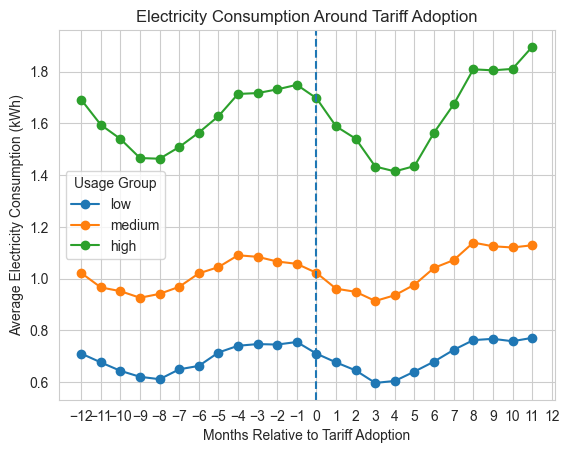

In [31]:
# 有選 tariff 的人的用電量平均變化 (按用電總量分組)
plot_event_study_tariff(
    month_result[month_result["price"] == "low"],
    value_col="top3_mean_consumption",
    line_cols="usage_group",
    window=12
)

<Axes: title={'center': 'Electricity Consumption Around Tariff Adoption'}, xlabel='Months Relative to Tariff Adoption', ylabel='Average Electricity Consumption (kWh)'>

<Figure size 640x480 with 0 Axes>

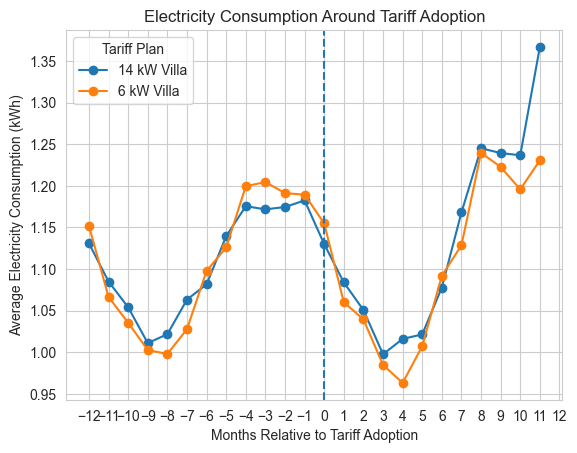

In [32]:
# 有選 tariff 的人的用電量平均變化 (按tariff plan 分組)
plot_event_study_tariff(
    month_result[month_result["price"] == "all"],
    value_col="top3_mean_consumption",
    line_cols="tariff_plan",
    window=12
)

<Axes: title={'center': 'Electricity Consumption Around Tariff Adoption'}, xlabel='Months Relative to Tariff Adoption', ylabel='Average Electricity Consumption (kWh)'>

<Figure size 640x480 with 0 Axes>

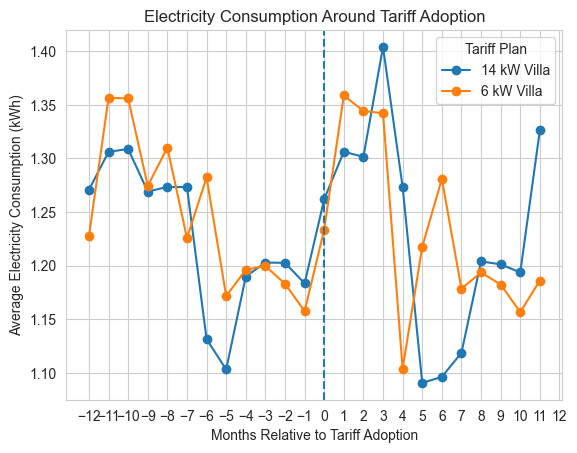

In [33]:
# 有選 tariff 的人的用電量平均變化 (按tariff plan 分組)
plot_event_study_tariff(
    month_result[month_result["price"] == "high"],
    value_col="top3_mean_consumption",
    line_cols="tariff_plan",
    window=12
)

<Axes: title={'center': 'Electricity Consumption Around Tariff Adoption'}, xlabel='Months Relative to Tariff Adoption', ylabel='Average Electricity Consumption (kWh)'>

<Figure size 640x480 with 0 Axes>

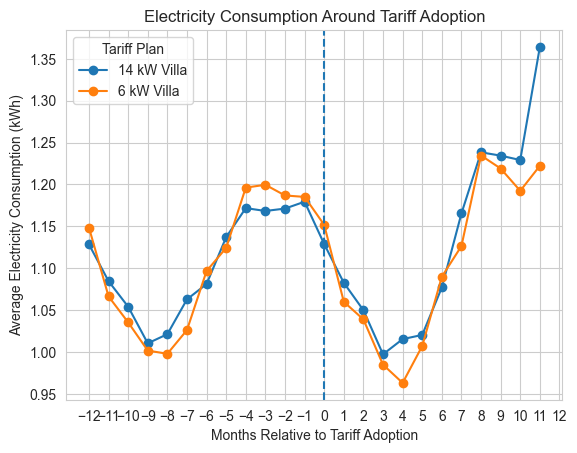

In [34]:
# 有選 tariff 的人的用電量平均變化 (按tariff plan 分組)
plot_event_study_tariff(
    month_result[month_result["price"] == "low"],
    value_col="top3_mean_consumption",
    line_cols="tariff_plan",
    window=12
)

<Axes: title={'center': 'Electricity Consumption Around Tariff Adoption'}, xlabel='Months Relative to Tariff Adoption', ylabel='Average Electricity Consumption (kWh)'>

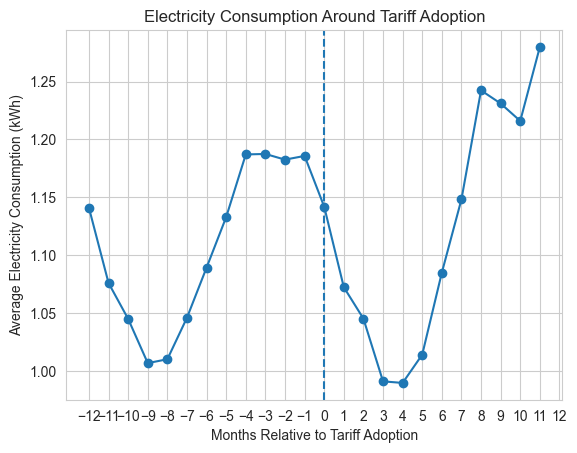

In [35]:
# 有選 tariff 的人的用電量平均變化
plot_event_study_tariff(
    month_result[month_result["price"] == "all"],
    value_col="top3_mean_consumption",
    window=12
)

<Axes: title={'center': 'Electricity Consumption Around Tariff Adoption'}, xlabel='Months Relative to Tariff Adoption', ylabel='Average Electricity Consumption (kWh)'>

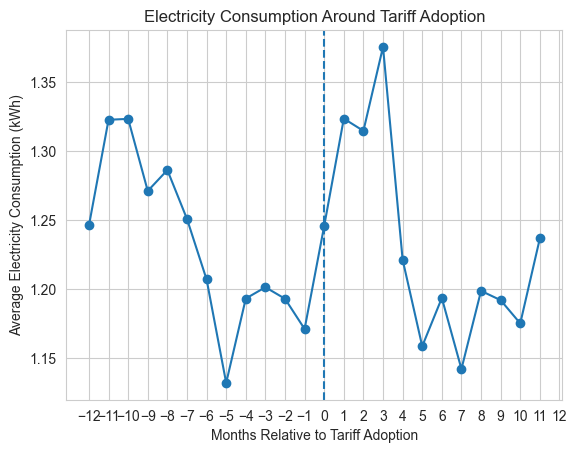

In [36]:
# 有選 tariff 的人的用電量平均變化 (按tariff plan 分組)
plot_event_study_tariff(
    month_result[month_result["price"] == "high"],
    value_col="top3_mean_consumption",
    window=12
)

<Axes: title={'center': 'Electricity Consumption Around Tariff Adoption'}, xlabel='Months Relative to Tariff Adoption', ylabel='Average Electricity Consumption (kWh)'>

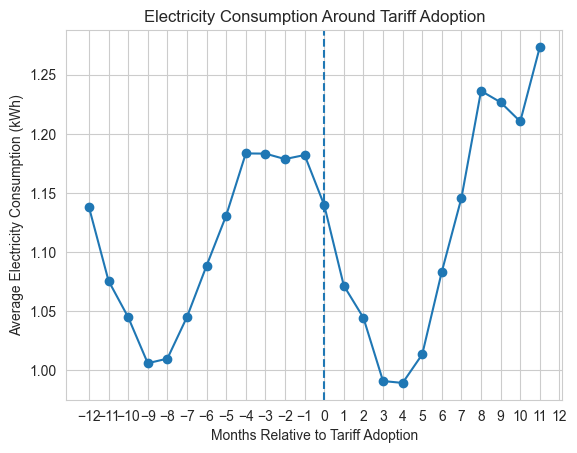

In [37]:
# 有選 tariff 的人的用電量平均變化 (按tariff plan 分組)
plot_event_study_tariff(
    month_result[month_result["price"] == "low"],
    value_col="top3_mean_consumption",
    window=12
)

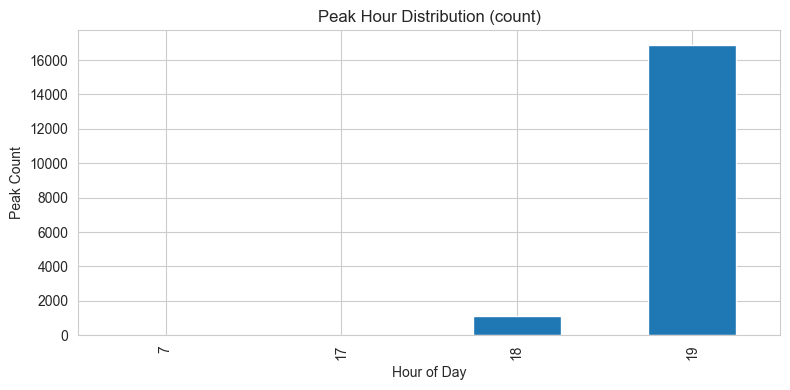

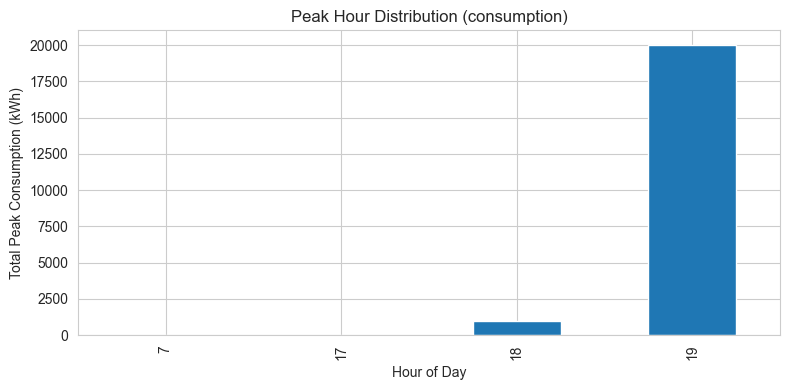

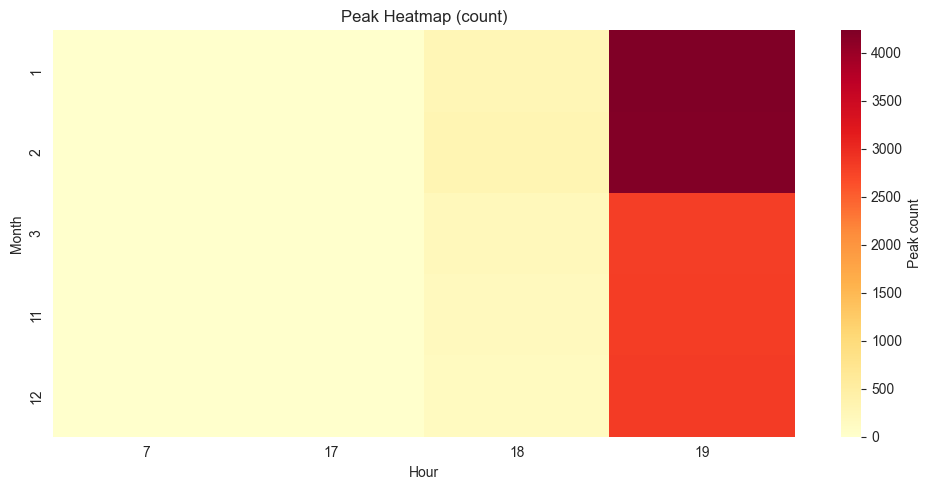

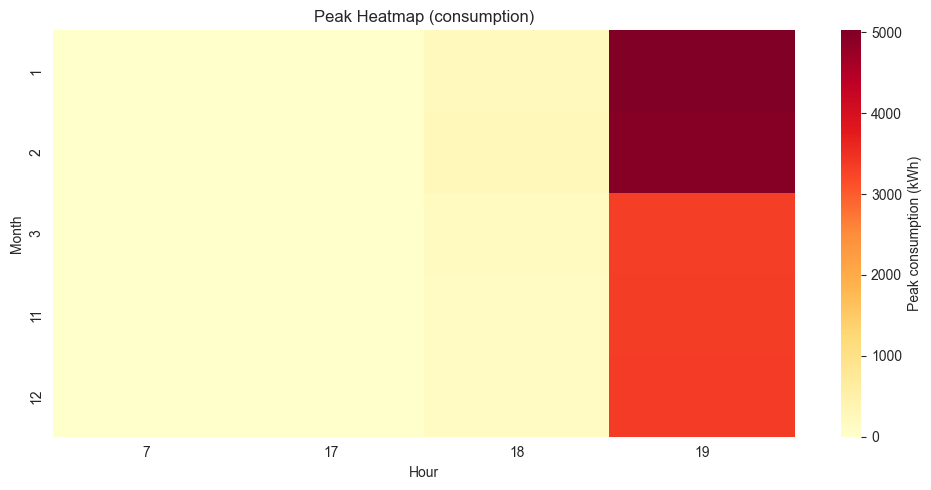

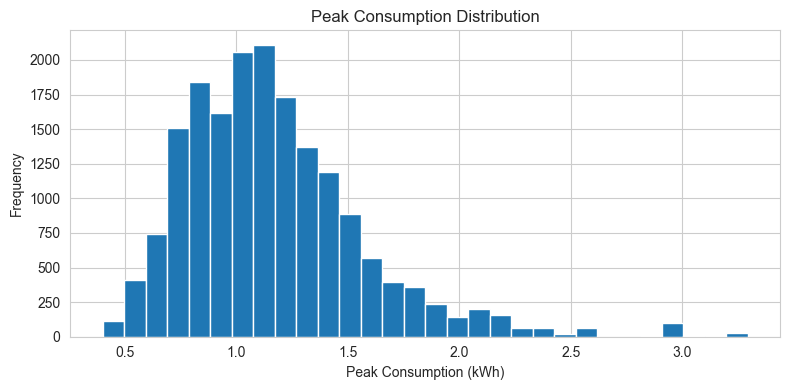

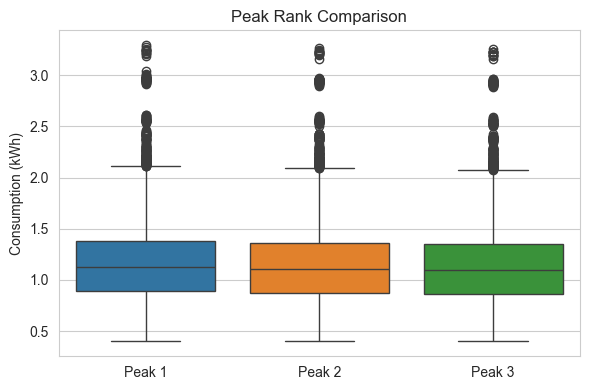

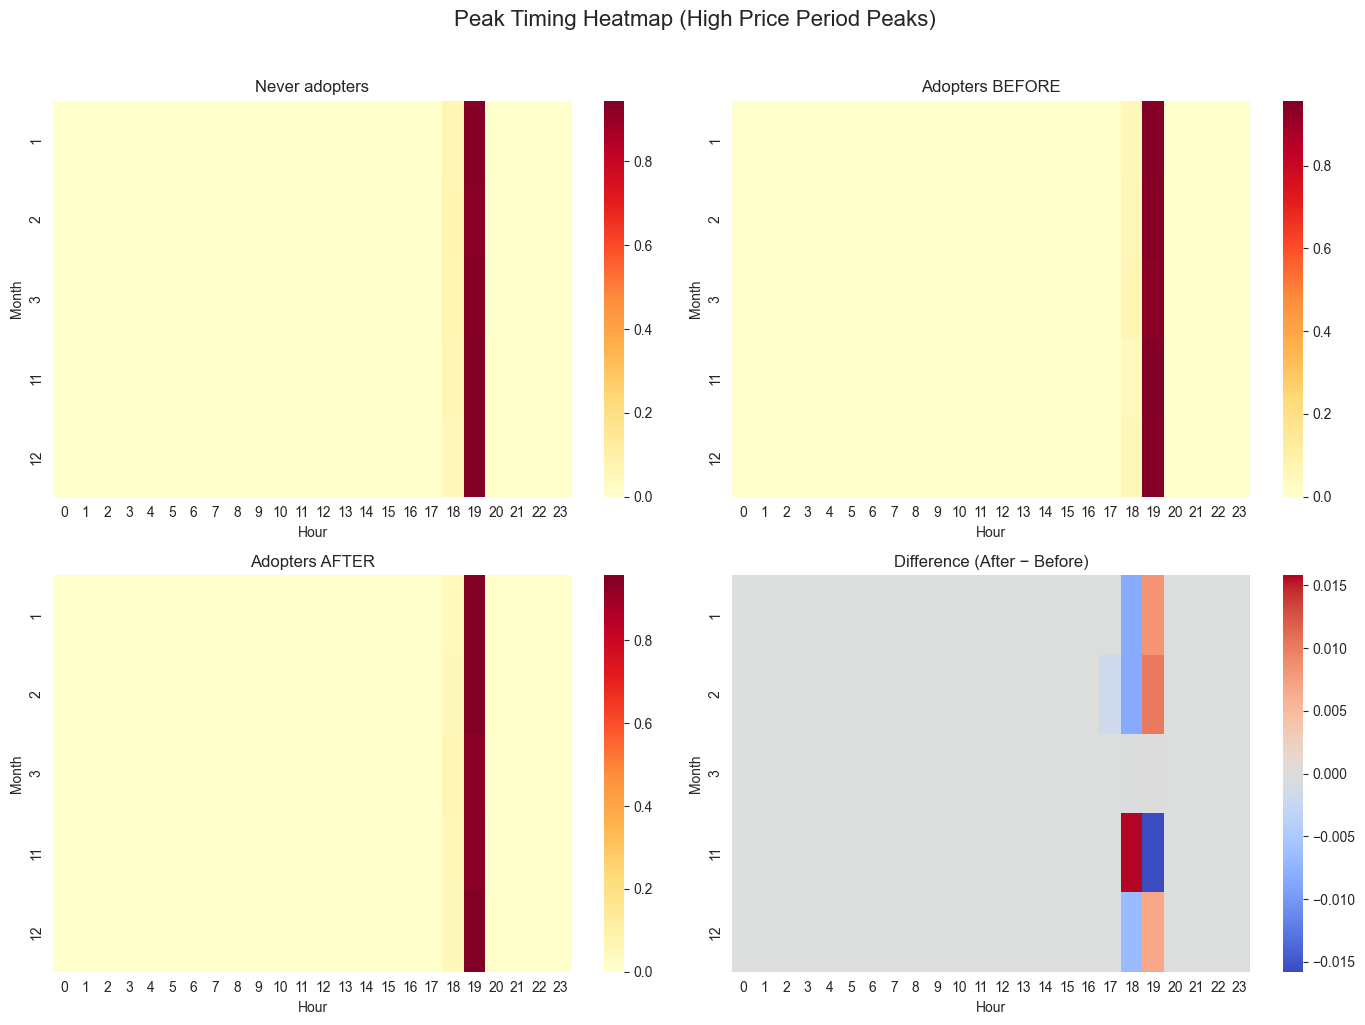

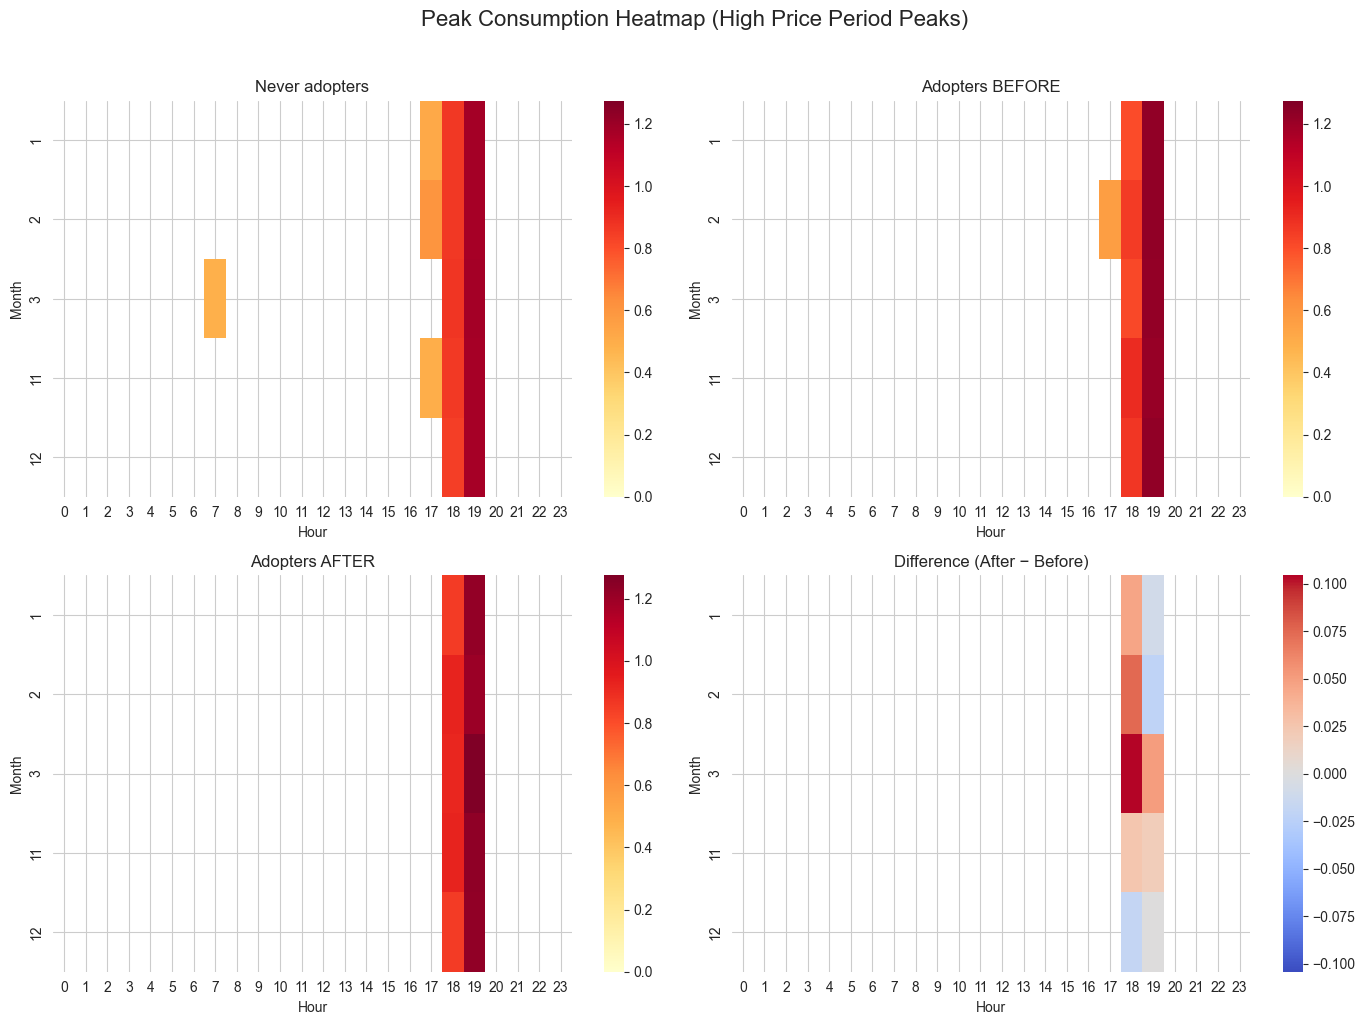

In [38]:
# Peak hour distribution (count)
# 看 peak 最常發生在一天的哪個小時
pp.plot_peak_hour_distribution(month_result[month_result["price"] == "high"])

# Peak hour distribution (consumption)
# 看哪個小時的 peak 用電量總和最高（電網壓力）
pp.plot_peak_hour_distribution(
    month_result[month_result["price"] == "high"],
    mode="consumption"
)

# Peak heatmap (count)
# Month × Hour heatmap，看不同月份 peak 最常出現的時間
pp.plot_peak_heatmap(month_result[month_result["price"] == "high"])

# Peak heatmap (consumption)
# Month × Hour heatmap，但用顏色表示 peak 用電量
pp.plot_peak_heatmap(
    month_result[month_result["price"] == "high"],
    mode="consumption"
)

# Peak consumption distribution
# Histogram，看 peak demand 的大小分布（household peak size）
pp.plot_peak_consumption_distribution(
    month_result[month_result["price"] == "high"]
)

# Peak rank boxplot
# 比較 peak1 / peak2 / peak3 的用電量分布，看 spike 程度
pp.plot_peak_rank_boxplot(
    month_result[month_result["price"] == "high"]
)

# Peak timing heatmap: P(hour | peak)
# 比較 tariff 前後 peak 發生次數的 Month × Hour heatmap
pp.plot_tariff_peak_heatmap(
    month_result[month_result["price"] == "high"],
    price_label="high"
)

# # Peak consumption heatmap: E(consumption | peak hour)
pp.plot_tariff_consumption_heatmap(
    month_result[month_result["price"] == "high"],
    price_label="high"
)

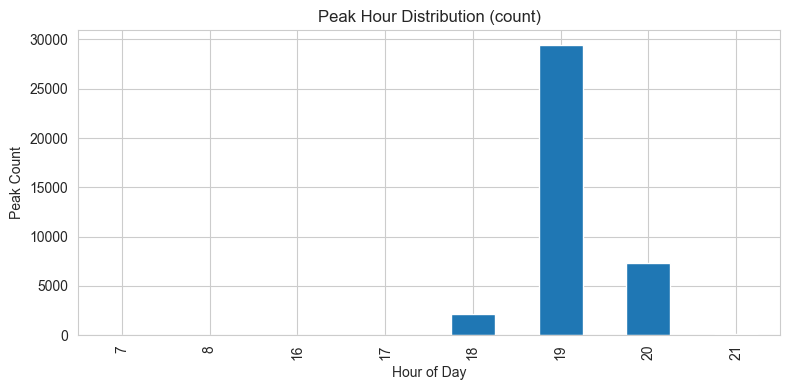

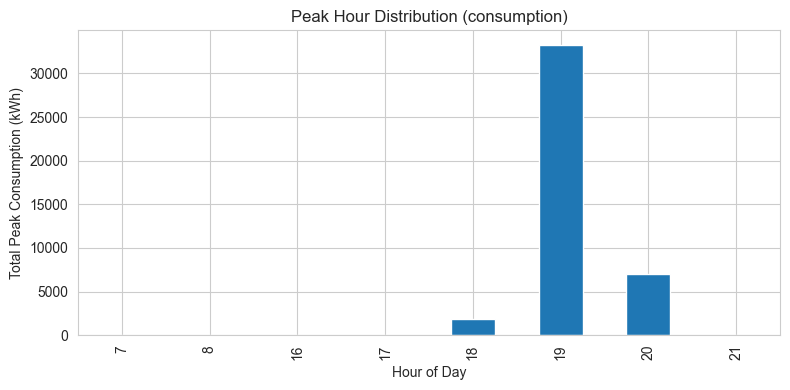

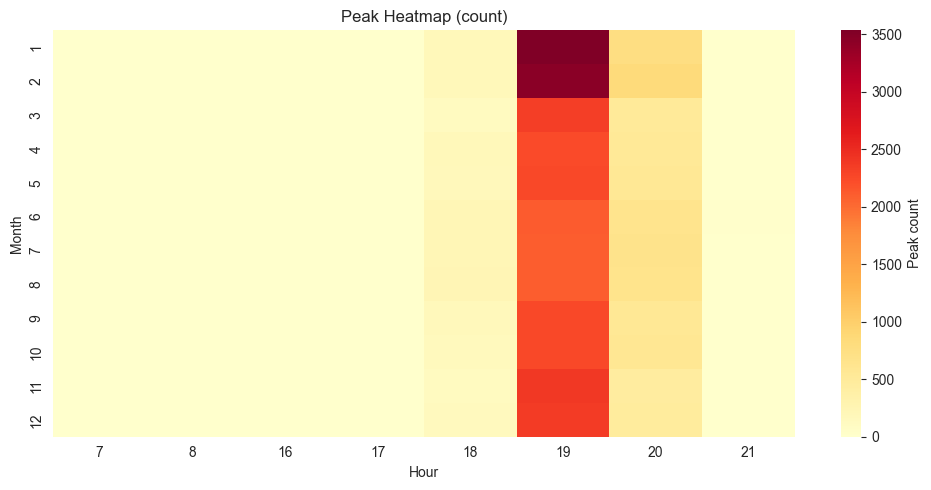

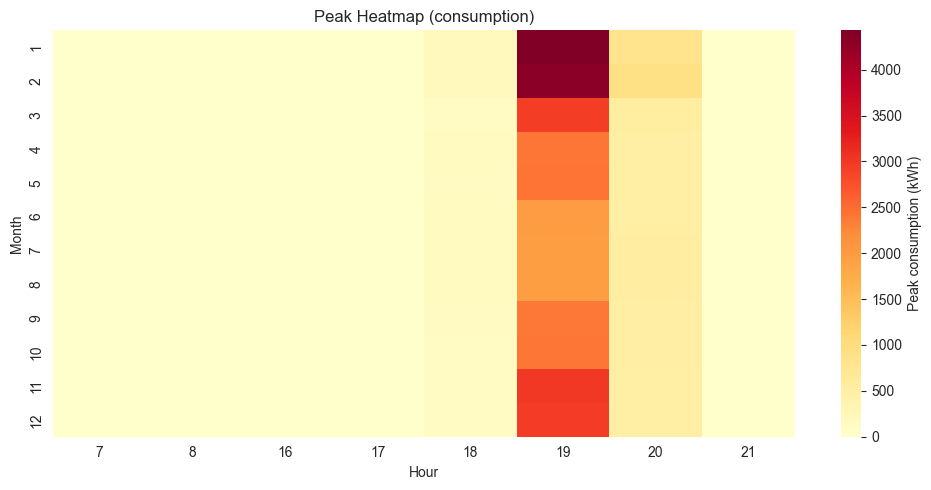

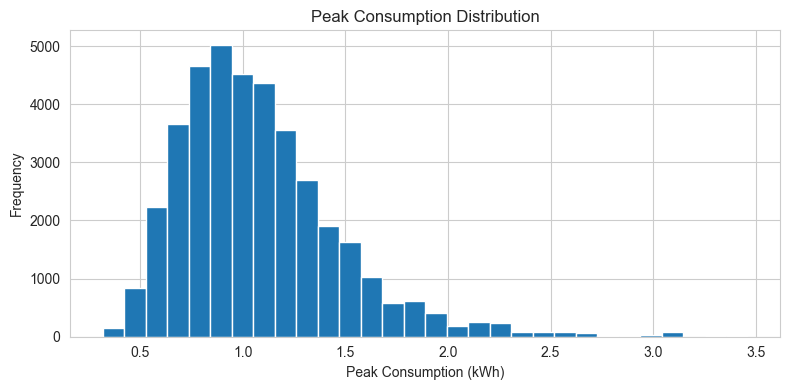

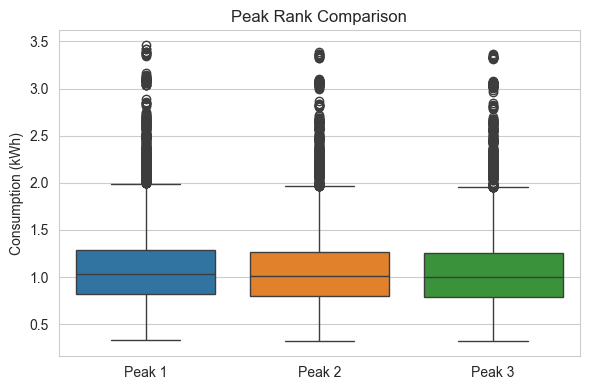

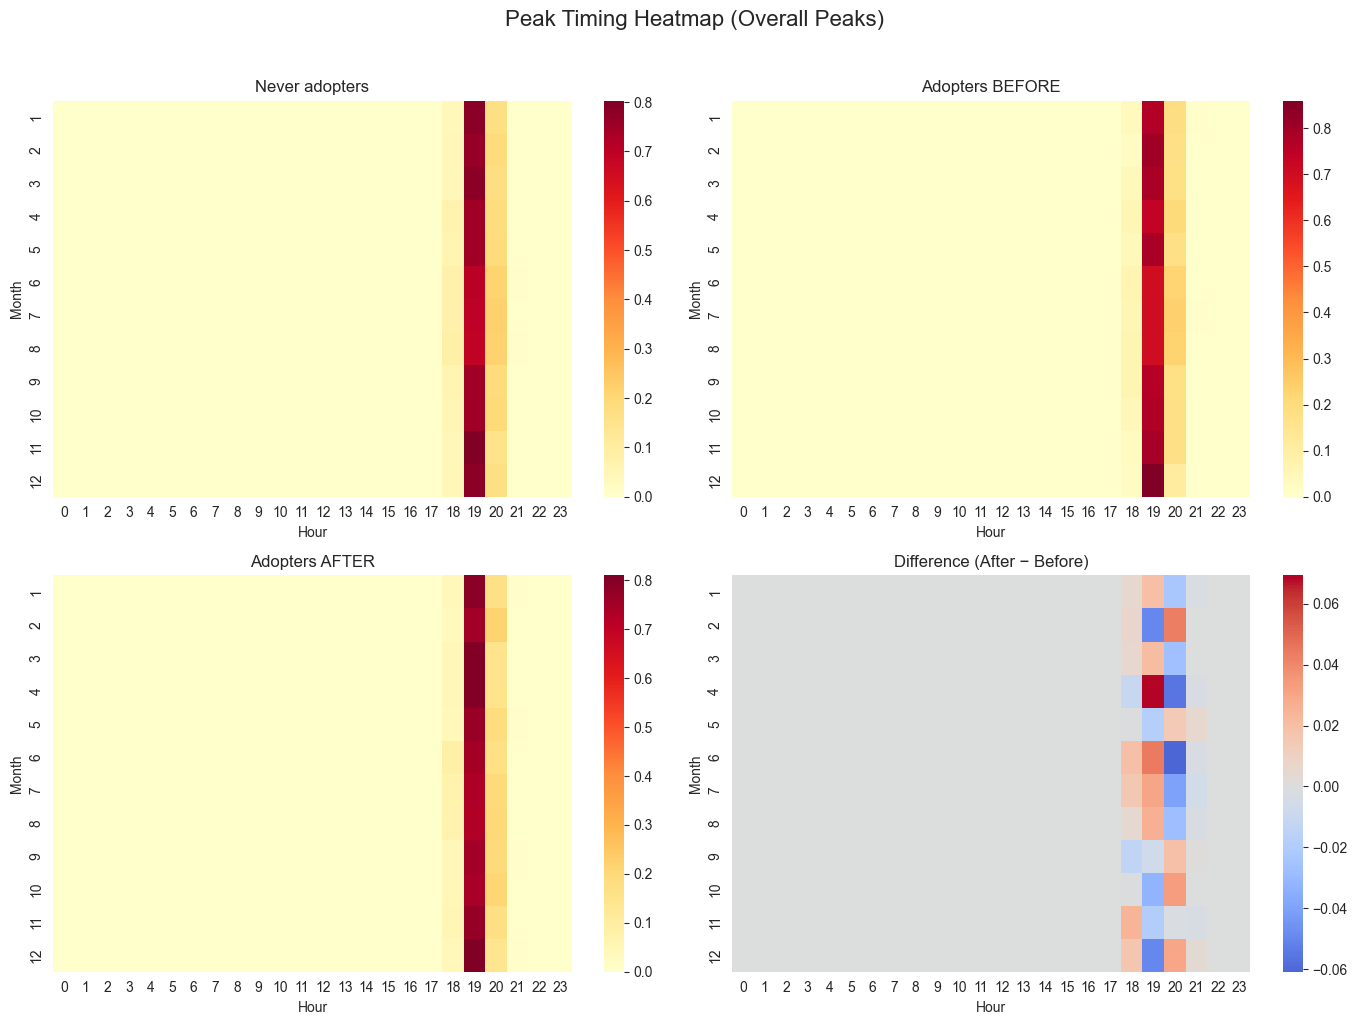

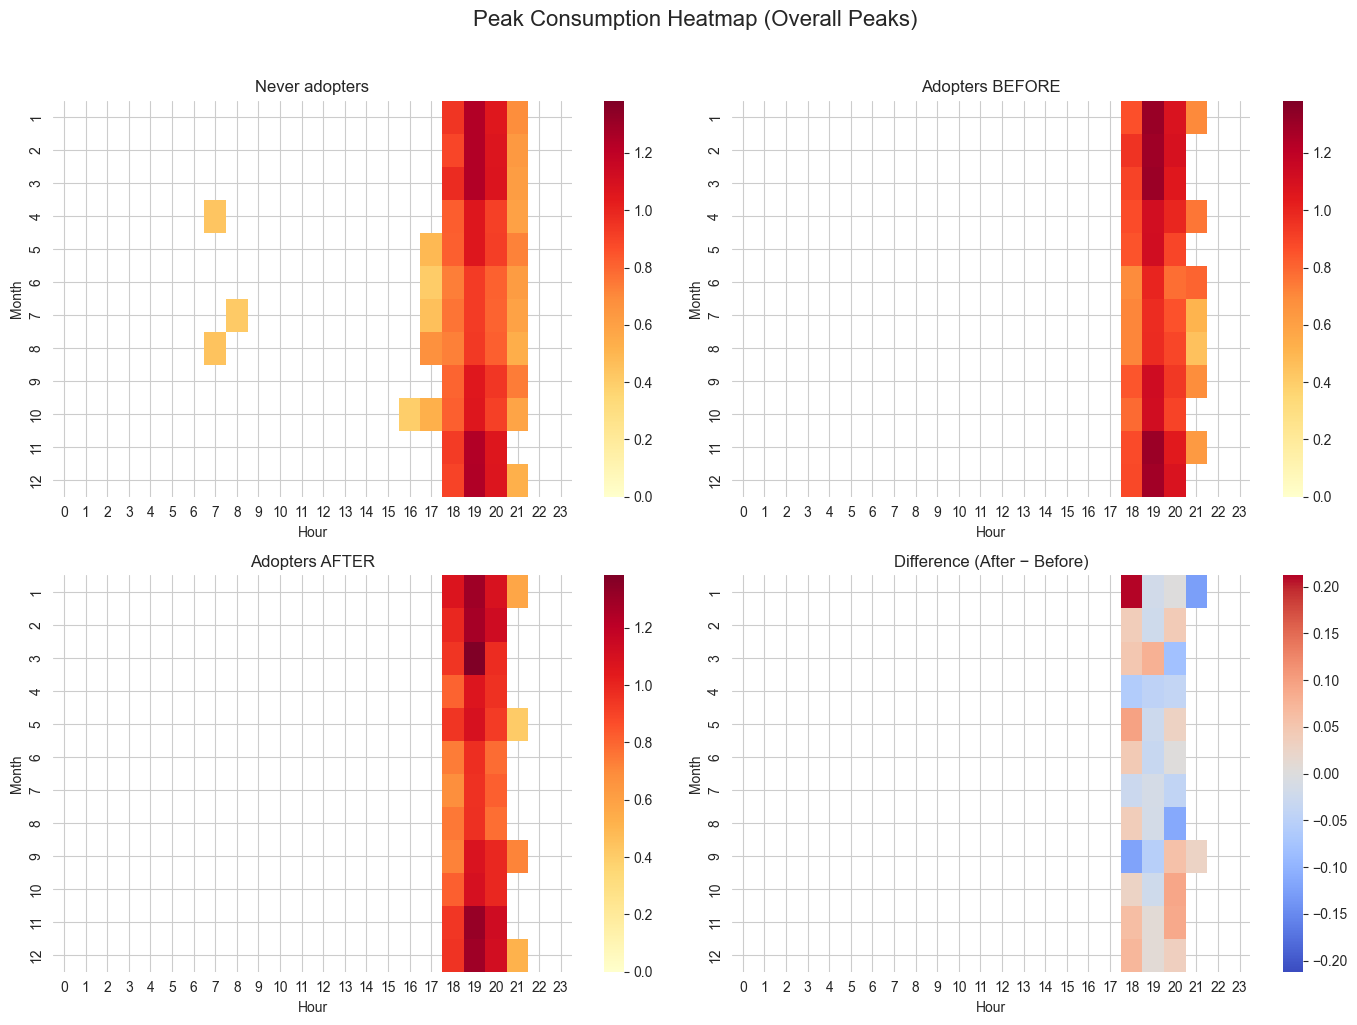

In [39]:
# Overall peak analysis
# Peak hour distribution (count)
pp.plot_peak_hour_distribution(month_result[month_result["price"] == "all"])

# Peak hour distribution (consumption)
pp.plot_peak_hour_distribution(
    month_result[month_result["price"] == "all"],
    mode="consumption"
)

# Peak heatmap (count)
pp.plot_peak_heatmap(month_result[month_result["price"] == "all"])

# Peak heatmap (consumption)
pp.plot_peak_heatmap(
    month_result[month_result["price"] == "all"],
    mode="consumption"
)

# Peak consumption distribution
pp.plot_peak_consumption_distribution(
    month_result[month_result["price"] == "all"]
)

# Peak rank boxplot
pp.plot_peak_rank_boxplot(
    month_result[month_result["price"] == "all"]
)

# Peak timing heatmap: P(hour | peak)
pp.plot_tariff_peak_heatmap(
    month_result[month_result["price"] == "all"], 
    price_label="all"
)

# # Peak consumption heatmap: E(consumption | peak hour)
pp.plot_tariff_consumption_heatmap(
    month_result[month_result["price"] == "all"],
    price_label="all"
)


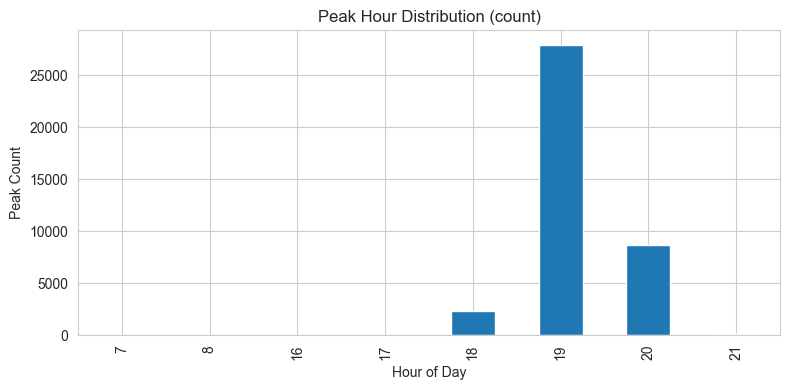

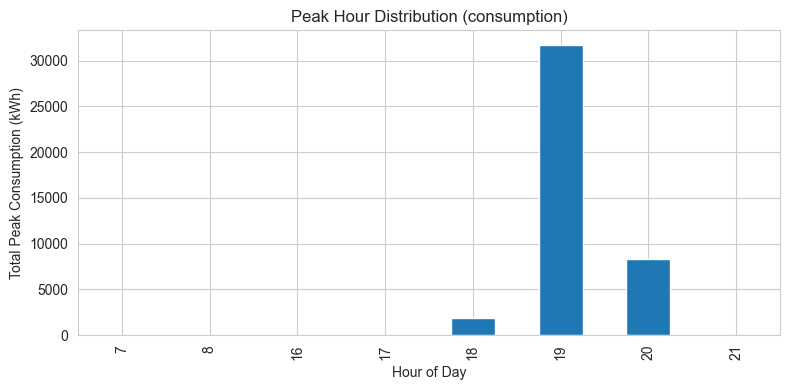

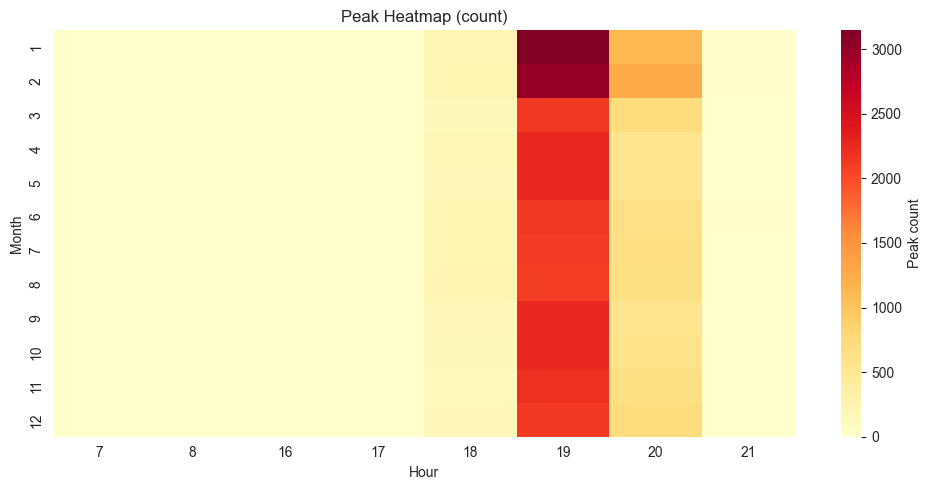

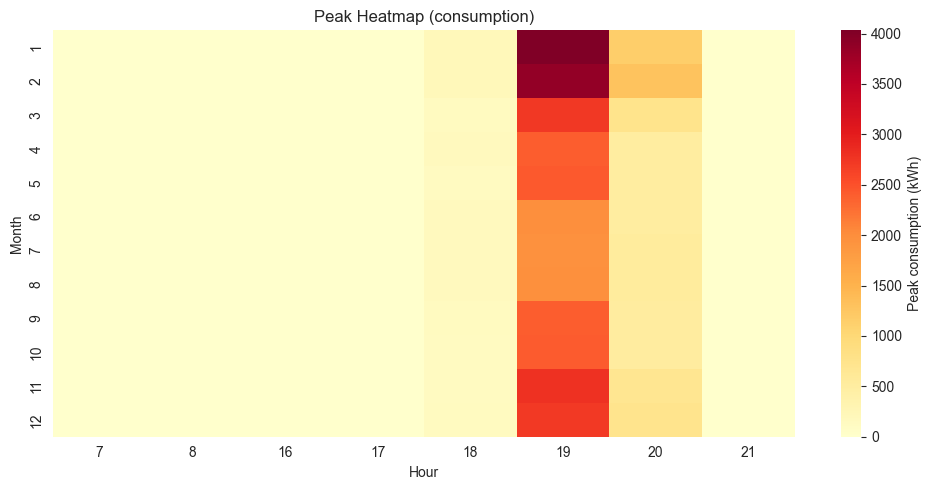

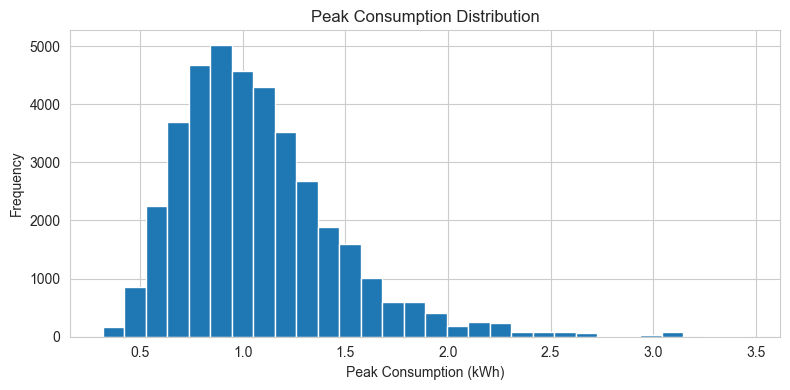

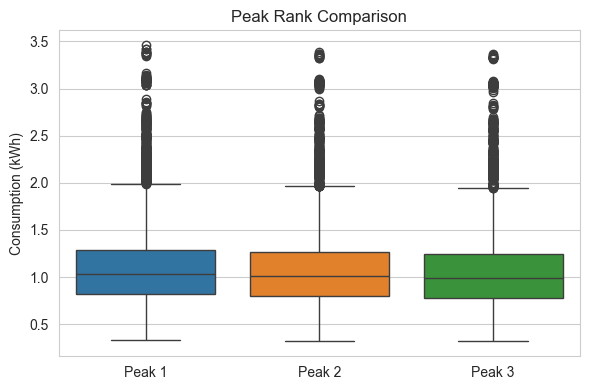

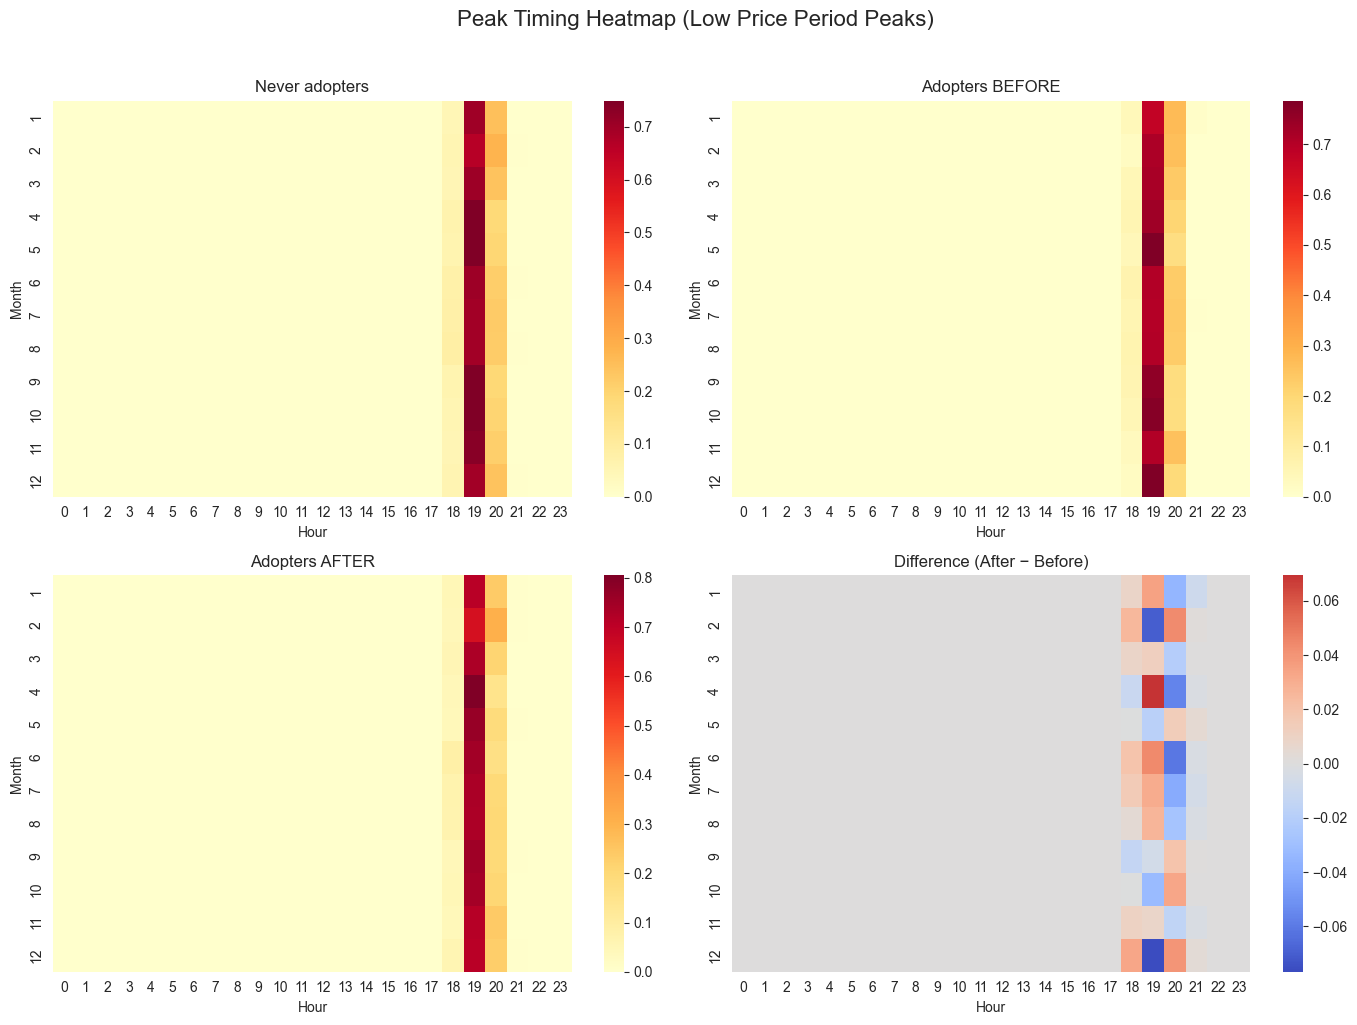

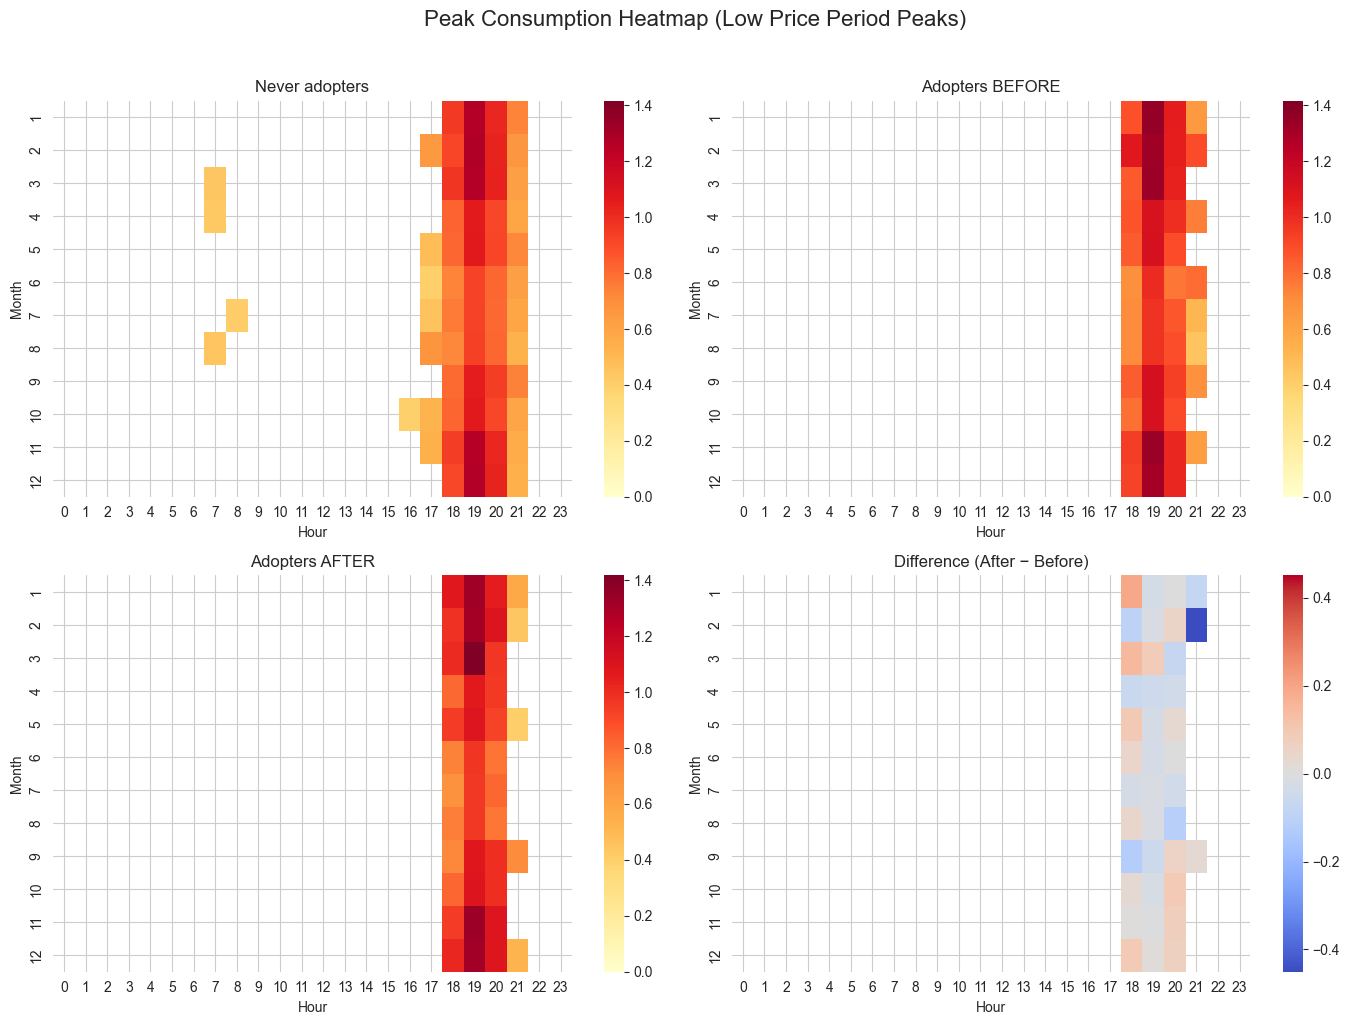

In [40]:
# Low peak analysis
# Peak hour distribution (count)
pp.plot_peak_hour_distribution(month_result[month_result["price"] == "low"])

# Peak hour distribution (consumption)
pp.plot_peak_hour_distribution(
    month_result[month_result["price"] == "low"],
    mode="consumption"
)

# Peak heatmap (count)
pp.plot_peak_heatmap(month_result[month_result["price"] == "low"])

# Peak heatmap (consumption)
pp.plot_peak_heatmap(
    month_result[month_result["price"] == "low"],
    mode="consumption"
)

# Peak consumption distribution
pp.plot_peak_consumption_distribution(
    month_result[month_result["price"] == "low"]
)

# Peak rank boxplot
pp.plot_peak_rank_boxplot(
    month_result[month_result["price"] == "low"]
)

# Peak timing heatmap: P(hour | peak)
pp.plot_tariff_peak_heatmap(
    month_result[month_result["price"] == "low"],
    price_label="low"
)


# # Peak consumption heatmap: E(consumption | peak hour)
pp.plot_tariff_consumption_heatmap(
    month_result[month_result["price"] == "low"],
    price_label="low"
)


## Look at specific month

In [41]:
# plot_cohort_calendar(
#     month_result,
#     cohort_month="2025-03"
# )
# plot_cohort_calendar(
#     month_result,
#     cohort_month="2025-04"
# )

<Axes: title={'center': 'Average Peak Consumption by Tariff Adoption Month'}, xlabel='Month', ylabel='Average Consumption (kWh)'>

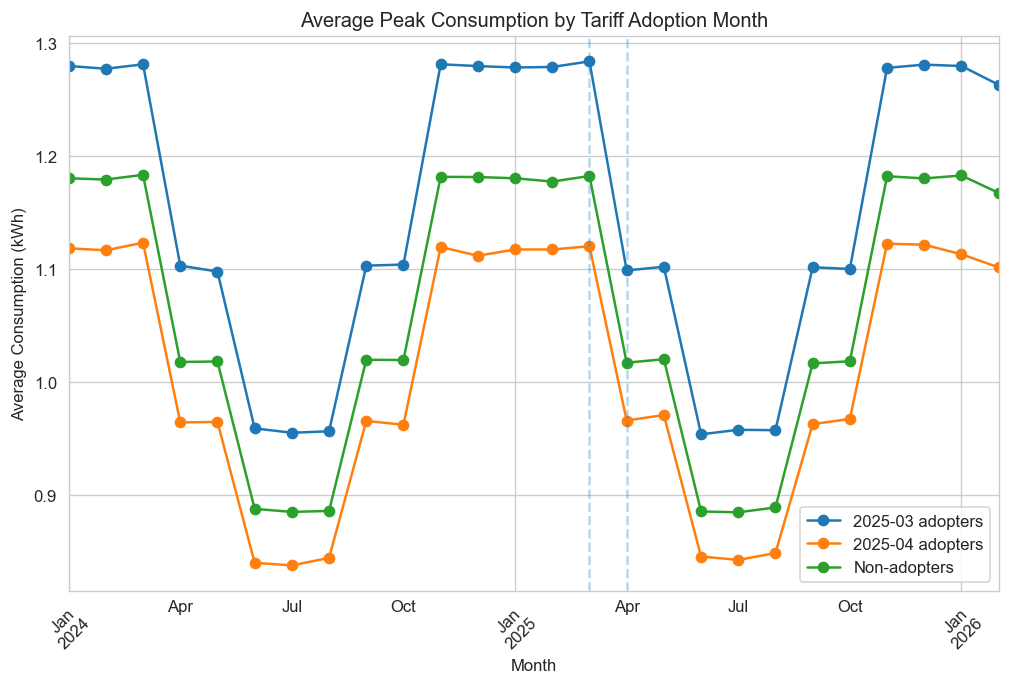

In [42]:
plot_multiple_cohorts(
    month_result,
    cohort_months=["2025-03", "2025-04", ]
)

<Axes: title={'center': 'Average Peak Consumption by Tariff Adoption Month'}, xlabel='Month', ylabel='Average Consumption (kWh)'>

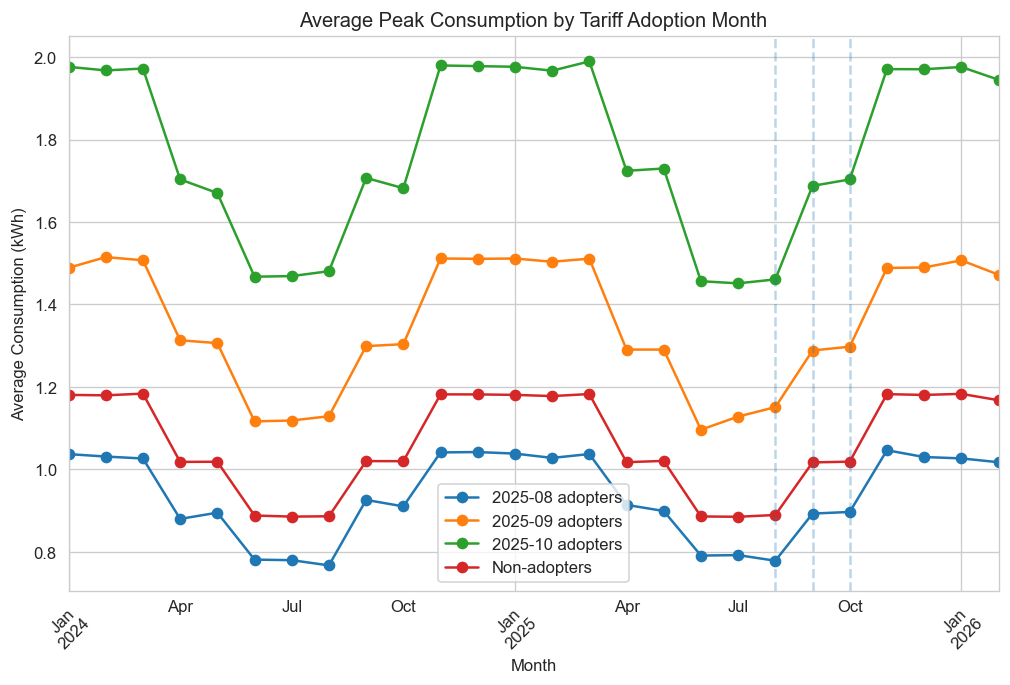

In [43]:
plot_multiple_cohorts(
    month_result,
    cohort_months=["2025-08", "2025-09", "2025-10"]
)

array([<Axes: title={'center': 'Mar 2025 adopters'}, xlabel='TIDPUNKT', ylabel='Consumption (kWh)'>,
       <Axes: title={'center': 'Apr 2025 adopters'}, xlabel='TIDPUNKT'>,
       <Axes: title={'center': 'May 2025 adopters'}, xlabel='TIDPUNKT', ylabel='Consumption (kWh)'>,
       <Axes: title={'center': 'Jun 2025 adopters'}, xlabel='TIDPUNKT'>,
       <Axes: title={'center': 'Jul 2025 adopters'}, xlabel='TIDPUNKT', ylabel='Consumption (kWh)'>,
       <Axes: title={'center': 'Aug 2025 adopters'}, xlabel='TIDPUNKT'>],
      dtype=object)

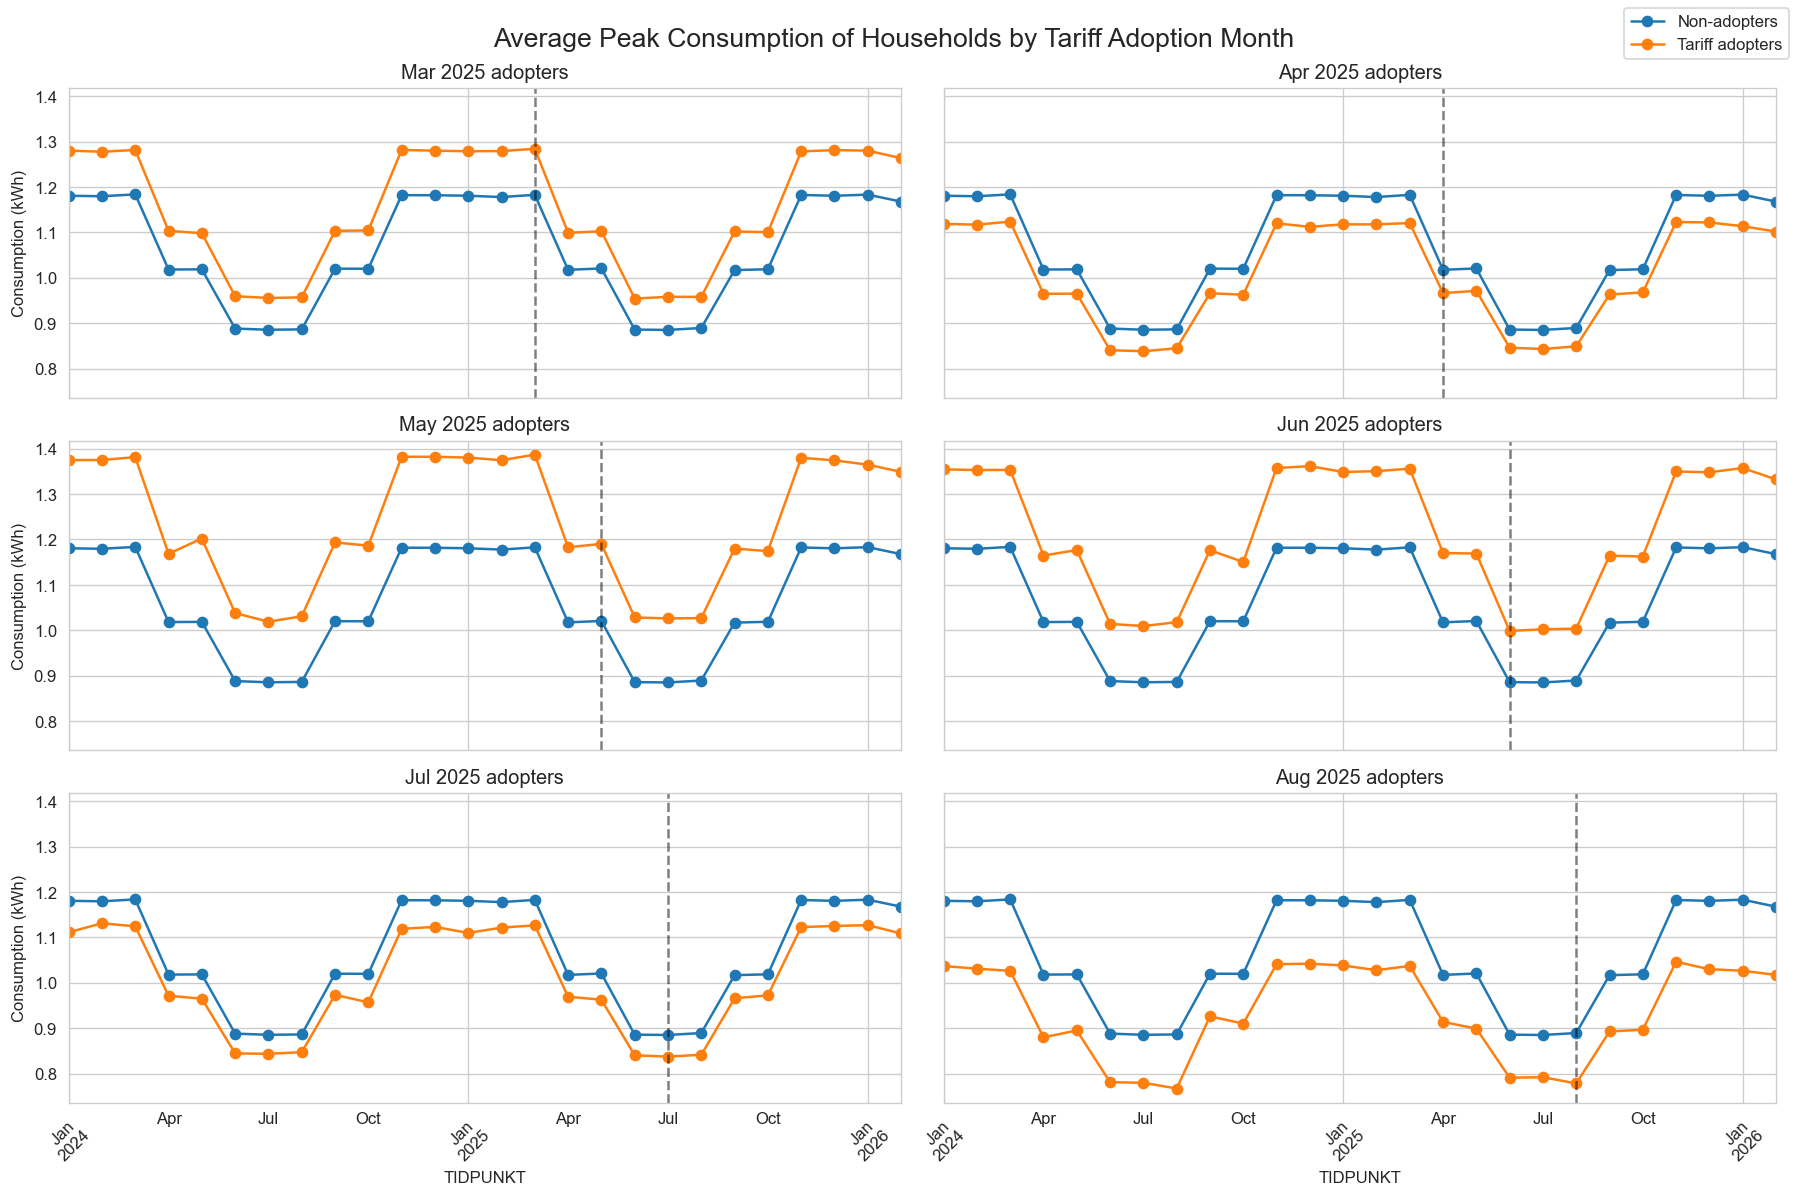

In [44]:
plot_cohort_panels(
    month_result,
    cohort_months=[
        "2025-03", "2025-04", "2025-05",
        "2025-06", "2025-07", "2025-08"
    ],
    ncols=2
)